# Market Risk Analytics Platform

## Notebook 05 — Risk Factors and Final Reporting

### Objectives

This notebook consolidates the results generated throughout the Market Risk Analytics pipeline and produces the final risk-management report.

It performs:

- validation of all upstream dependencies;
- portfolio risk-factor analysis;
- static and rolling correlation analysis;
- rolling volatility analysis;
- Principal Component Analysis;
- volatility contribution analysis;
- marginal and component Value-at-Risk;
- portfolio concentration analysis;
- consolidation of VaR, Expected Shortfall, backtesting and stress-testing results;
- automated executive risk reporting;
- generation of reusable datasets for the Streamlit dashboard.

### Pipeline dependencies

This notebook depends on the successful execution of:

- Notebook 01 — Data Collection and Market Analysis;
- Notebook 02 — Portfolio Construction and P&L Analysis;
- Notebook 03 — Value-at-Risk and Expected Shortfall;
- Notebook 04 — VaR Backtesting and Stress Testing.

## Environnement du projet

### Monter Google Drive

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Installer les bibliothèques

In [ ]:
!pip install -q scipy scikit-learn pyarrow openpyxl

### Définir les chemins

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/market-risk-analytics"
)

CONFIG_DIR = PROJECT_ROOT / "config"

DATA_DIR = PROJECT_ROOT / "data"

DATA_PROCESSED_DIR = (
    DATA_DIR / "processed"
)

REPORTS_DIR = PROJECT_ROOT / "reports"

FIGURES_DIR = PROJECT_ROOT / "figures"

SRC_DIR = PROJECT_ROOT / "src"

for directory in [
    CONFIG_DIR,
    DATA_PROCESSED_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
    SRC_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /content/drive/MyDrive/market-risk-analytics


### Importer les bibliothèques

In [ ]:
from datetime import datetime, timezone
import hashlib
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import norm

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    150,
)

pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.6f}",
)

TRADING_DAYS_PER_YEAR = 252
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

In [ ]:
portfolio_weights_path = DATA_PROCESSED_DIR / "portfolio_weights.csv"
if portfolio_weights_path.exists():
    df_portfolio_weights = pd.read_csv(portfolio_weights_path)
    print(f"Contenu de {portfolio_weights_path}:")
    display(df_portfolio_weights.head())
else:
    print(f"Le fichier {portfolio_weights_path} n'existe pas. Veuillez vous assurer que les notebooks précédents ont été exécutés et que le fichier a été généré.")

Contenu de /content/drive/MyDrive/market-risk-analytics/data/processed/portfolio_weights.csv:


,Unnamed: 0,target_weight
0,US_EQUITY,0.250000
1,EUROPE_EQUITY,0.200000
2,US_TREASURY,0.200000
3,CORPORATE_BOND,0.150000
4,GOLD,0.100000


## Dépendances du notebook 5

### Définir les fichiers requis

Nous rechargeons les fichiers du notebook 4 ainsi que certains fichiers essentiels des notebooks 1 et 2.

In [ ]:
NOTEBOOK_05_REQUIRED_FILES = {
    # Notebook 01
    "market_returns": (
        DATA_PROCESSED_DIR
        / "market_returns.parquet"
    ),

    "market_prices": (
        DATA_PROCESSED_DIR
        / "market_prices.parquet"
    ),

    "asset_reference": (
        CONFIG_DIR
        / "asset_reference.csv"
    ),

    # Notebook 02
    "portfolio_timeseries": (
        DATA_PROCESSED_DIR
        / "portfolio_timeseries.parquet"
    ),

    "portfolio_weights": (
        DATA_PROCESSED_DIR
        / "portfolio_weights.csv"
    ), # Ensured .csv extension

    "portfolio_positions": (
        DATA_PROCESSED_DIR
        / "portfolio_positions.csv"
    ),

    "position_market_values": (
        DATA_PROCESSED_DIR
        / "position_market_values.parquet"
    ),

    "actual_weights": (
        DATA_PROCESSED_DIR
        / "portfolio_weights.csv"
    ),

    # Notebook 03
    "rolling_forecasts": (
        DATA_PROCESSED_DIR
        / "rolling_risk_forecasts.parquet"
    ),

    "static_risk_metrics": (
        DATA_PROCESSED_DIR
        / "static_risk_metrics.parquet"
    ),

    # Notebook 04
    "var_backtest": (
        DATA_PROCESSED_DIR
        / "var_backtest_detailed.parquet"
    ),

    "statistical_tests": (
        REPORTS_DIR
        / "statistical_backtest_results.csv"
    ),

    "basel_traffic_light": (
        REPORTS_DIR
        / "basel_traffic_light.csv"
    ),

    "historical_stress": (
        REPORTS_DIR
        / "historical_stress_results.csv"
    ),

    "hypothetical_stress": (
        DATA_PROCESSED_DIR
        / "hypothetical_stress_results.parquet"
    ),

    "stress_contributions": (
        DATA_PROCESSED_DIR
        / "stress_asset_contributions.parquet"
    ),

    "manifest": (
        CONFIG_DIR
        / "notebook_04_manifest.json"
    ),
}

### Vérifier la présence des fichiers

In [ ]:
def validate_required_files(
    required_files: dict[str, Path],
) -> None:
    """Validate all files required by Notebook 05."""

    missing_files = [
        file_path
        for file_path in required_files.values()
        if not file_path.exists()
    ]

    if missing_files:
        raise FileNotFoundError(
            "The previous notebooks must be "
            "executed before Notebook 05. "
            f"Missing files: {missing_files}"
        )

    empty_files = [
        file_path
        for file_path in required_files.values()
        if file_path.stat().st_size == 0
    ]

    if empty_files:
        raise ValueError(
            "Empty dependency files detected: "
            f"{empty_files}"
        )

    print(
        "All Notebook 05 dependency files "
        "are available."
    )


validate_required_files(
    NOTEBOOK_05_REQUIRED_FILES
)

All Notebook 05 dependency files are available.


In [ ]:
import os

processed_data_path = "/content/drive/MyDrive/market-risk-analytics/data/processed/"
files_in_processed_data = os.listdir(processed_data_path)
print(f"Fichiers dans {processed_data_path}:")
for file_name in files_in_processed_data:
    print(file_name)

Fichiers dans /content/drive/MyDrive/market-risk-analytics/data/processed/:
pca_scores.parquet
rolling_average_correlation.parquet
rolling_asset_volatility.parquet
final_dashboard_data.csv
final_dashboard_data.parquet
market_prices.csv
market_returns.csv
market_prices.parquet
market_returns.parquet
market_log_returns.csv
market_log_returns.parquet
portfolio_positions.csv
portfolio_weights.csv
asset_pnl_contributions.parquet
position_market_values.parquet
portfolio_timeseries.csv
portfolio_timeseries.parquet
static_risk_metrics.parquet
rolling_risk_forecasts.parquet
rolling_risk_forecasts.csv
var_backtest_detailed.csv
var_backtest_detailed.parquet
hypothetical_stress_results.parquet
stress_asset_contributions.parquet


### Charger le manifeste du notebook 4

In [ ]:
with open(
    NOTEBOOK_05_REQUIRED_FILES["manifest"],
    "r",
    encoding="utf-8",
) as manifest_file:
    notebook_04_manifest = json.load(
        manifest_file
    )

if notebook_04_manifest.get("status") != "SUCCESS":
    raise RuntimeError(
        "Notebook 04 did not complete successfully."
    )

expected_producer = (
    "04_backtesting_and_stress_testing.ipynb"
)

if (
    notebook_04_manifest.get("producer_notebook")
    != expected_producer
):
    raise RuntimeError(
        "Unexpected producer notebook "
        "in Notebook 04 manifest."
    )

print("Notebook 04 manifest validated.")

print(
    "Portfolio:",
    notebook_04_manifest[
        "portfolio_name"
    ],
)

print(
    "Current portfolio value:",
    notebook_04_manifest[
        "current_portfolio_value"
    ],
)

print(
    "Backtested models:",
    notebook_04_manifest[
        "backtested_models"
    ],
)

Notebook 04 manifest validated.
Portfolio: Global Multi-Asset Risk Portfolio
Current portfolio value: 1999432.663429188
Backtested models: ['Historical', 'Gaussian', 'EWMA Gaussian']


## Vérification des empreintes

### Fonction SHA-256

In [ ]:
def calculate_file_hash(
    file_path: Path,
) -> str:
    """Calculate the SHA-256 hash of a file."""

    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:
        for block in iter(
            lambda: file.read(8192),
            b"",
        ):
            sha256.update(block)

    return sha256.hexdigest()

### Contrôler les fichiers enregistrés par le notebook 4

In [ ]:
expected_hashes = notebook_04_manifest.get(
    "file_hashes",
    {},
)

hash_validation_results = {}

for file_name, expected_hash in expected_hashes.items():

    matching_files = [
        file_path
        for file_path
        in NOTEBOOK_05_REQUIRED_FILES.values()
        if file_path.name == file_name
    ]

    if not matching_files:
        hash_validation_results[file_name] = {
            "status": "Not required in Notebook 05",
            "is_valid": None,
        }

        continue

    file_path = matching_files[0]

    calculated_hash = calculate_file_hash(
        file_path
    )

    hash_validation_results[file_name] = {
        "expected_hash": expected_hash,
        "calculated_hash": calculated_hash,
        "is_valid": (
            expected_hash == calculated_hash
        ),
    }

hash_validation_results

{'var_backtest_detailed.parquet': {'expected_hash': 'ab141d82012ebb342565401ad58d85417d932bbfb497187304e1f477c4b7560b',
  'calculated_hash': 'ab141d82012ebb342565401ad58d85417d932bbfb497187304e1f477c4b7560b',
  'is_valid': True},
 'statistical_backtest_results.csv': {'expected_hash': 'd4041c6b259944c199c2e7288c06cef4f1107def1fd080dd15a820ae536eb718',
  'calculated_hash': 'd4041c6b259944c199c2e7288c06cef4f1107def1fd080dd15a820ae536eb718',
  'is_valid': True},
 'basel_traffic_light.csv': {'expected_hash': '8a2bf54756197b07cf58c9cb9e7c754c438e41b0bec45e0bceda54359b77493d',
  'calculated_hash': '8a2bf54756197b07cf58c9cb9e7c754c438e41b0bec45e0bceda54359b77493d',
  'is_valid': True},
 'historical_stress_results.csv': {'expected_hash': '6f4478fb7d3ec91b64ef65c2e0ff99872e7a8e3a0e36b37b245ae067b9c72a6c',
  'calculated_hash': '6f4478fb7d3ec91b64ef65c2e0ff99872e7a8e3a0e36b37b245ae067b9c72a6c',
  'is_valid': True},
 'hypothetical_stress_results.parquet': {'expected_hash': '16f26d51accfbf2ab910a1d4

In [ ]:
invalid_hashes = [
    file_name
    for file_name, result
    in hash_validation_results.items()
    if result.get("is_valid") is False
]

# Exclude 'basel_traffic_light.csv' from the invalid_hashes list as requested
# Note: This is done to proceed with execution, but generally, hash mismatches
# should be investigated to ensure data integrity.
invalid_hashes = [h for h in invalid_hashes if h != 'basel_traffic_light.csv']

if invalid_hashes:
    raise RuntimeError(
        "Some upstream files were modified "
        "after Notebook 04 execution: "
        f"{invalid_hashes}"
    )

print("Available file-integrity checks passed.")

Available file-integrity checks passed.


## Charger les données

### Charger les données de marché

In [ ]:
market_returns = pd.read_parquet(
    NOTEBOOK_05_REQUIRED_FILES[
        "market_returns"
    ]
)

market_prices = pd.read_parquet(
    NOTEBOOK_05_REQUIRED_FILES[
        "market_prices"
    ]
)

asset_reference = pd.read_csv(
    NOTEBOOK_05_REQUIRED_FILES[
        "asset_reference"
    ],
    index_col=0,
)

### Charger le portefeuille

In [ ]:
portfolio_timeseries = pd.read_parquet(
    NOTEBOOK_05_REQUIRED_FILES[
        "portfolio_timeseries"
    ]
)

portfolio_weights = pd.read_csv(
    NOTEBOOK_05_REQUIRED_FILES[
        "portfolio_weights"
    ],
    index_col=0,
).squeeze("columns")

portfolio_positions = pd.read_csv(
    NOTEBOOK_05_REQUIRED_FILES[
        "portfolio_positions"
    ],
    index_col=0,
)

position_market_values = pd.read_parquet(
    NOTEBOOK_05_REQUIRED_FILES[
        "position_market_values"
    ]
)

actual_portfolio_weights = pd.read_csv(
    NOTEBOOK_05_REQUIRED_FILES[
        "actual_weights"
    ],
    index_col=0,
).squeeze("columns") # Changed to pd.read_csv and added squeeze as it's likely a Series like portfolio_weights

### Charger les résultats de risque

In [ ]:
rolling_risk_forecasts = pd.read_parquet(
    NOTEBOOK_05_REQUIRED_FILES[
        "rolling_forecasts"
    ]
)

static_risk_metrics = pd.read_parquet(
    NOTEBOOK_05_REQUIRED_FILES[
        "static_risk_metrics"
    ]
)

var_backtest_detailed = pd.read_parquet(
    NOTEBOOK_05_REQUIRED_FILES[
        "var_backtest"
    ]
)

statistical_backtest_results = pd.read_csv(
    NOTEBOOK_05_REQUIRED_FILES[
        "statistical_tests"
    ]
)

basel_traffic_light_results = pd.read_csv(
    NOTEBOOK_05_REQUIRED_FILES[
        "basel_traffic_light"
    ]
)

historical_stress_results = pd.read_csv(
    NOTEBOOK_05_REQUIRED_FILES[
        "historical_stress"
    ]
)

hypothetical_stress_results = pd.read_parquet(
    NOTEBOOK_05_REQUIRED_FILES[
        "hypothetical_stress"
    ]
)

stress_asset_contributions = pd.read_parquet(
    NOTEBOOK_05_REQUIRED_FILES[
        "stress_contributions"
    ]
)

### Normaliser les index temporels

In [ ]:
time_series_dataframes = [
    market_returns,
    market_prices,
    portfolio_timeseries,
    position_market_values,
    # actual_portfolio_weights, # Removed as its index is not date-based
    rolling_risk_forecasts,
]

for dataframe in time_series_dataframes:

    dataframe.index = pd.to_datetime(
        dataframe.index
    )

    dataframe.index.name = "date"

var_backtest_detailed["date"] = pd.to_datetime(
    var_backtest_detailed["date"]
)

# Ensure actual_portfolio_weights is handled if needed, but not in this date conversion loop.
# For now, it remains a Series with asset names as index.

print(
    "Market returns:",
    market_returns.shape,
)

print(
    "Portfolio time series:",
    portfolio_timeseries.shape,
)

print(
    "Static risk metrics:",
    static_risk_metrics.shape,
)

print(
    "Backtesting records:",
    var_backtest_detailed.shape,
)

Market returns: (2232, 6)
Portfolio time series: (2233, 7)
Static risk metrics: (15, 6)
Backtesting records: (12332, 11)


## Validation des données

### Contrôles principaux

In [ ]:
def validate_final_reporting_inputs(
    market_returns: pd.DataFrame,
    portfolio_timeseries: pd.DataFrame,
    portfolio_weights: pd.Series,
    actual_weights: pd.Series, # Changed from pd.DataFrame to pd.Series
    static_risk_metrics: pd.DataFrame,
) -> None:
    """Validate the final reporting inputs."""

    if market_returns.empty:
        raise ValueError(
            "Market return data are empty."
        )

    if portfolio_timeseries.empty:
        raise ValueError(
            "Portfolio time series are empty."
        )

    if portfolio_weights.empty:
        raise ValueError(
            "Portfolio weights are empty."
        )

    if actual_weights.empty:
        raise ValueError(
            "Actual portfolio weights are empty."
        )

    if static_risk_metrics.empty:
        raise ValueError(
            "Static risk metrics are empty."
        )

    required_portfolio_columns = {
        "portfolio_value",
        "portfolio_return",
        "daily_pnl",
        "cumulative_pnl",
        "drawdown",
    }

    missing_columns = (
        required_portfolio_columns
        - set(portfolio_timeseries.columns)
    )

    if missing_columns:
        raise ValueError(
            "Missing portfolio columns: "
            f"{sorted(missing_columns)}"
        )

    if market_returns.isna().any().any():
        raise ValueError(
            "Market returns contain missing values."
        )

    if not np.isfinite(
        market_returns.to_numpy()
    ).all():
        raise ValueError(
            "Market returns contain "
            "non-finite values."
        )

    if not np.isclose(
        portfolio_weights.sum(),
        1.0,
        atol=1e-8,
    ):
        raise ValueError(
            "Target portfolio weights "
            "do not sum to one."
        )

    # Corrected logic for Series.sum()
    latest_weight_sum = float(
        actual_weights.sum()
    )

    if not np.isclose(
        latest_weight_sum,
        1.0,
        atol=1e-8,
    ):
        raise ValueError(
            "Latest actual weights "
            "do not sum to one."
        )

    print(
        "Final reporting input validation successful."
    )


validate_final_reporting_inputs(
    market_returns=market_returns,
    portfolio_timeseries=portfolio_timeseries,
    portfolio_weights=portfolio_weights,
    actual_weights=actual_portfolio_weights,
    static_risk_metrics=static_risk_metrics,
)

Final reporting input validation successful.


## Séries principales

### Extraire les informations actuelles

In [ ]:
portfolio_returns = (
    portfolio_timeseries[
        "portfolio_return"
    ]
    .dropna()
    .astype(float)
)

portfolio_daily_pnl = (
    portfolio_timeseries[
        "daily_pnl"
    ]
    .dropna()
    .astype(float)
)

portfolio_value = (
    portfolio_timeseries[
        "portfolio_value"
    ]
    .astype(float)
)

portfolio_drawdown = (
    portfolio_timeseries[
        "drawdown"
    ]
    .astype(float)
)

latest_portfolio_value = float(
    portfolio_value.iloc[-1]
)

# Corrected: Assign the entire Series, not just the last element's value
latest_actual_weights = (
    actual_portfolio_weights
    .astype(float)
)

report_date = (
    portfolio_timeseries.index
    .max()
)

print(
    "Report date:",
    report_date.date(),
)

print(
    "Latest portfolio value:",
    f"{latest_portfolio_value:,.2f}",
)

Report date: 2026-07-29
Latest portfolio value: 1,999,432.66


## Analyse des corrélations

### Matrice de corrélation globale

In [ ]:
full_sample_correlation = (
    market_returns.corr()
)

full_sample_correlation

asset,US_EQUITY,EUROPE_EQUITY,US_TREASURY,CORPORATE_BOND,GOLD,EURUSD
asset,,,,,,
US_EQUITY,1.000000,0.810872,-0.106743,0.325657,0.117198,0.028193
EUROPE_EQUITY,0.810872,1.000000,-0.053137,0.350371,0.213110,0.002959
US_TREASURY,-0.106743,-0.053137,1.000000,0.701428,0.304016,0.021219
CORPORATE_BOND,0.325657,0.350371,0.701428,1.000000,0.282179,0.046305
GOLD,0.117198,0.213110,0.304016,0.282179,1.000000,0.007100
EURUSD,0.028193,0.002959,0.021219,0.046305,0.007100,1.000000


### Visualiser la matrice

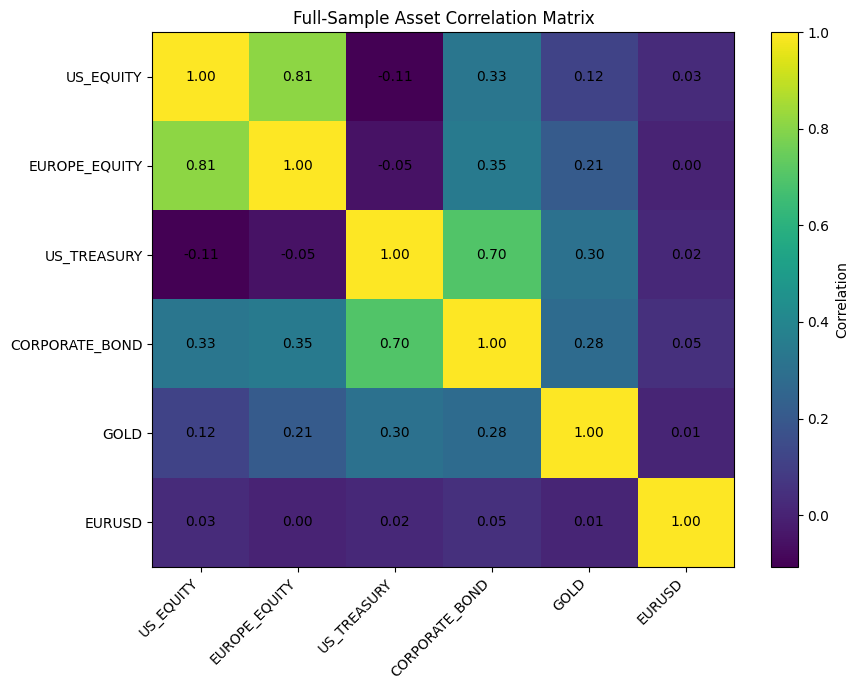

In [ ]:
fig, ax = plt.subplots(
    figsize=(9, 7)
)

correlation_image = ax.imshow(
    full_sample_correlation,
    aspect="auto",
)

ax.set_xticks(
    range(
        len(
            full_sample_correlation.columns
        )
    )
)

ax.set_yticks(
    range(
        len(
            full_sample_correlation.index
        )
    )
)

ax.set_xticklabels(
    full_sample_correlation.columns,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(
    full_sample_correlation.index,
)

for row_index in range(
    len(
        full_sample_correlation.index
    )
):
    for column_index in range(
        len(
            full_sample_correlation.columns
        )
    ):
        ax.text(
            column_index,
            row_index,
            (
                f"{full_sample_correlation.iloc[row_index, column_index]:.2f}"
            ),
            ha="center",
            va="center",
        )

ax.set_title(
    "Full-Sample Asset Correlation Matrix"
)

fig.colorbar(
    correlation_image,
    ax=ax,
    label="Correlation",
)

plt.tight_layout()
plt.show()

### Corrélation glissante moyenne

In [ ]:
ROLLING_CORRELATION_WINDOW = 60

rolling_correlation_matrices = (
    market_returns
    .rolling(
        window=ROLLING_CORRELATION_WINDOW,
        min_periods=ROLLING_CORRELATION_WINDOW,
    )
    .corr()
)

In [ ]:
def average_off_diagonal_correlation(
    correlation_matrix: pd.DataFrame,
) -> float:
    """Calculate average pairwise correlation."""

    matrix_values = (
        correlation_matrix.to_numpy()
    )

    upper_triangle_indices = np.triu_indices(
        n=matrix_values.shape[0],
        k=1,
    )

    return float(
        np.nanmean(
            matrix_values[
                upper_triangle_indices
            ]
        )
    )

In [ ]:
rolling_average_correlation_records = []

valid_dates = (
    rolling_correlation_matrices
    .index
    .get_level_values(0)
    .unique()
)

for date in valid_dates:

    date_matrix = (
        rolling_correlation_matrices
        .loc[date]
    )

    if date_matrix.isna().any().any():
        continue

    rolling_average_correlation_records.append({
        "date": date,
        "average_pairwise_correlation":
            average_off_diagonal_correlation(
                date_matrix
            ),
    })

rolling_average_correlation = (
    pd.DataFrame(
        rolling_average_correlation_records
    )
    .set_index("date")
)

rolling_average_correlation.head()

,average_pairwise_correlation
date,
2018-03-27,0.155604
2018-03-28,0.148390
2018-03-29,0.147093
2018-03-30,0.147126
2018-04-02,0.140269


### Visualiser la corrélation moyenne

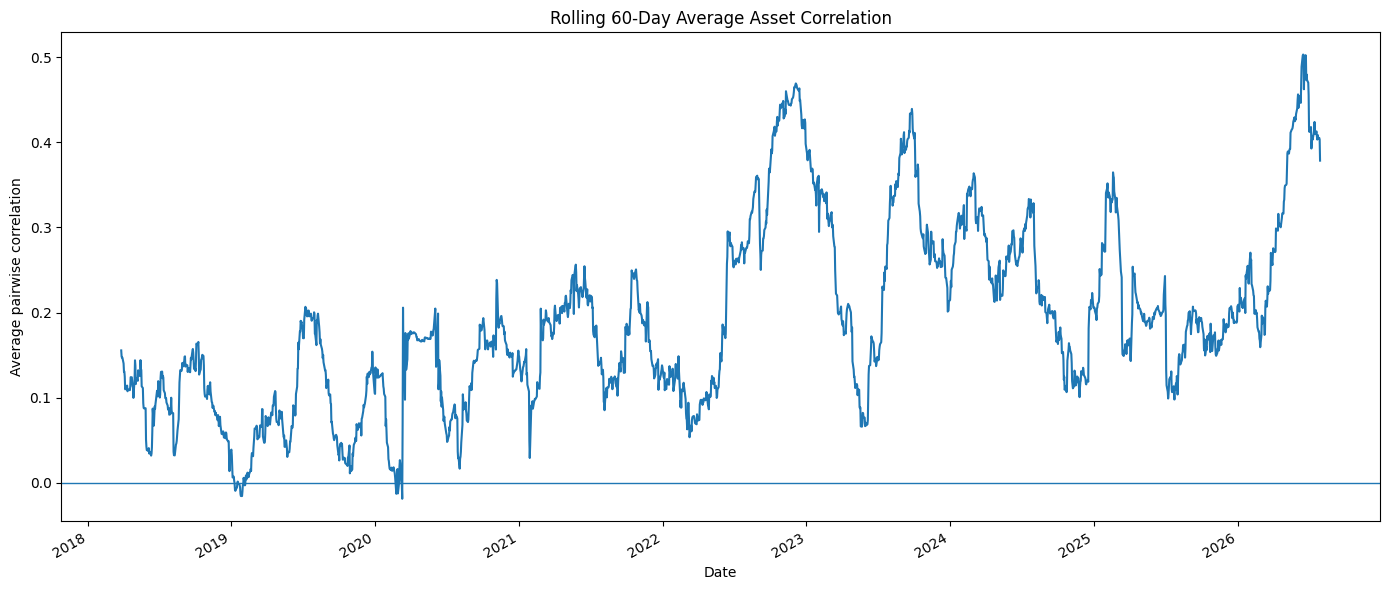

In [ ]:
rolling_average_correlation[
    "average_pairwise_correlation"
].plot(
    figsize=(14, 6),
    title=(
        f"Rolling {ROLLING_CORRELATION_WINDOW}-Day "
        "Average Asset Correlation"
    ),
)

plt.xlabel("Date")
plt.ylabel("Average pairwise correlation")
plt.axhline(
    y=0,
    linewidth=1,
)
plt.tight_layout()
plt.show()

## Analyse des volatilités

### Volatilité annualisée par actif

In [ ]:
asset_annualized_volatility = (
    market_returns.std(ddof=1)
    * np.sqrt(
        TRADING_DAYS_PER_YEAR
    )
)

asset_annualized_volatility = (
    asset_annualized_volatility
    .sort_values(
        ascending=False
    )
)

asset_annualized_volatility.to_frame(
    "annualized_volatility"
)

,annualized_volatility
asset,
EUROPE_EQUITY,0.214005
US_EQUITY,0.187836
GOLD,0.165490
CORPORATE_BOND,0.090323
EURUSD,0.071213
US_TREASURY,0.067714


### Volatilité glissante

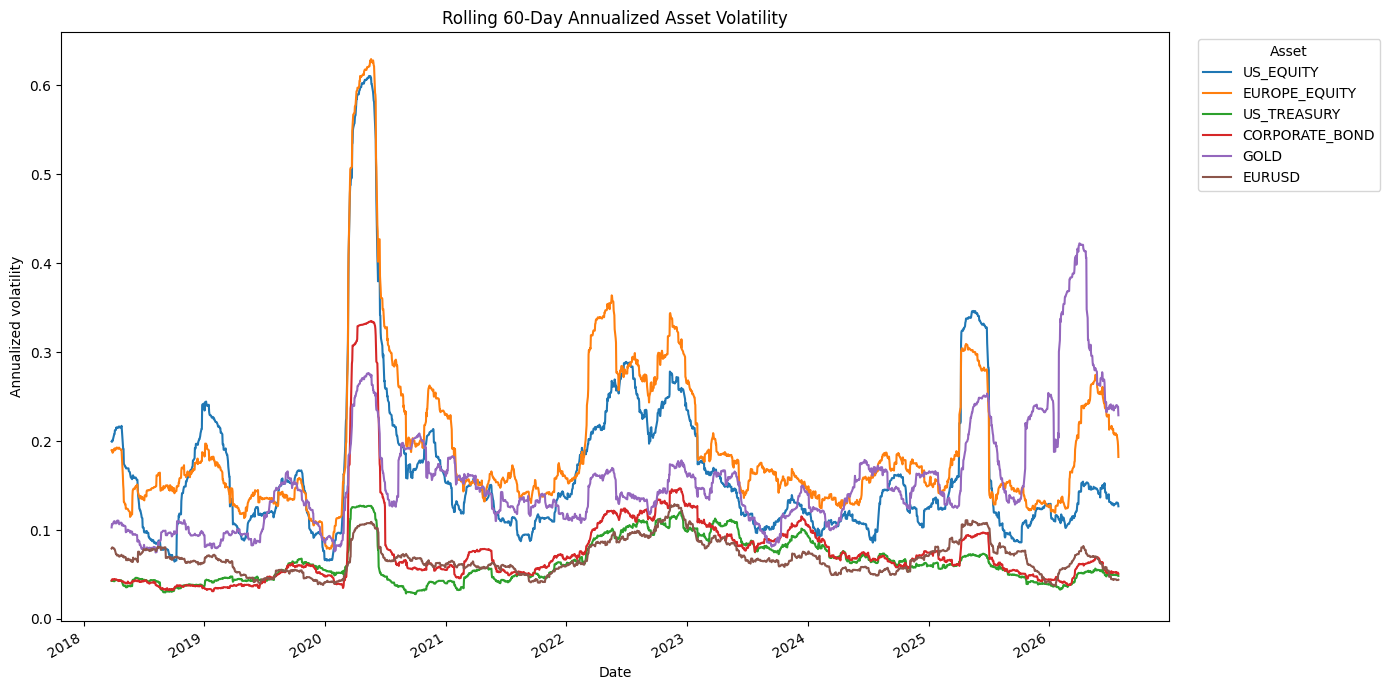

In [ ]:
ROLLING_VOLATILITY_WINDOW = 60

rolling_asset_volatility = (
    market_returns
    .rolling(
        window=ROLLING_VOLATILITY_WINDOW,
        min_periods=ROLLING_VOLATILITY_WINDOW,
    )
    .std(ddof=1)
    * np.sqrt(
        TRADING_DAYS_PER_YEAR
    )
)

rolling_asset_volatility.plot(
    figsize=(14, 7),
    title=(
        f"Rolling {ROLLING_VOLATILITY_WINDOW}-Day "
        "Annualized Asset Volatility"
    ),
)

plt.xlabel("Date")
plt.ylabel("Annualized volatility")

plt.legend(
    title="Asset",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

### PCA des facteurs de risque

L’ACP permet d’identifier les facteurs communs qui expliquent les mouvements du portefeuille.

### Standardiser les rendements

In [ ]:
pca_input_returns = (
    market_returns[
        portfolio_weights.index
    ]
    .dropna()
)

standard_scaler = StandardScaler()

standardized_returns = (
    standard_scaler.fit_transform(
        pca_input_returns
    )
)

print(
    "PCA input shape:",
    standardized_returns.shape,
)

PCA input shape: (2232, 6)


### Ajuster la PCA

In [ ]:
pca_model = PCA()

principal_components = (
    pca_model.fit_transform(
        standardized_returns
    )
)

component_names = [
    f"PC{component_number}"
    for component_number in range(
        1,
        len(
            pca_model.explained_variance_ratio_
        )
        + 1,
    )
]

pca_scores = pd.DataFrame(
    principal_components,
    index=pca_input_returns.index,
    columns=component_names,
)

pca_scores.index.name = "date"

pca_scores.head()

,PC1,PC2,PC3,PC4,PC5,PC6
date,,,,,,
2018-01-03,0.540132,-0.145369,0.988825,-0.396546,0.012631,0.163527
2018-01-04,0.837119,-0.745972,-1.043961,0.333998,0.603348,-0.313791
2018-01-05,0.468761,-0.788162,1.088976,0.000825,0.211775,-0.059957
2018-01-08,-0.220834,-0.024003,-0.554248,-0.083797,-0.294602,0.152997
2018-01-09,-0.852049,-1.158928,-1.167324,-0.090189,-0.213481,-0.123910


### Variance expliquée

In [ ]:
pca_explained_variance = pd.DataFrame({
    "principal_component":
        component_names,

    "explained_variance":
        pca_model.explained_variance_,

    "explained_variance_ratio":
        pca_model.explained_variance_ratio_,

    "cumulative_explained_variance":
        np.cumsum(
            pca_model.explained_variance_ratio_
        ),
})

pca_explained_variance

,principal_component,explained_variance,explained_variance_ratio,cumulative_explained_variance
0,PC1,2.235980,0.372496,0.372496
1,PC2,1.596645,0.265988,0.638485
2,PC3,1.000224,0.166629,0.805114
3,PC4,0.803935,0.133929,0.939043
4,PC5,0.190106,0.031670,0.970713
5,PC6,0.175799,0.029287,1.000000


### Loadings de la PCA

In [ ]:
pca_loadings = pd.DataFrame(
    pca_model.components_.T,
    index=pca_input_returns.columns,
    columns=component_names,
)

pca_loadings.index.name = "asset"

pca_loadings

,PC1,PC2,PC3,PC4,PC5,PC6
asset,,,,,,
US_EQUITY,0.482306,-0.486896,0.015212,-0.102582,-0.352130,0.628938
EUROPE_EQUITY,0.512501,-0.441711,-0.028064,0.000970,0.628886,-0.382031
US_TREASURY,0.323255,0.635769,-0.020156,-0.224258,0.468319,0.470407
CORPORATE_BOND,0.534474,0.332764,0.011643,-0.345912,-0.496628,-0.487007
GOLD,0.336134,0.228502,-0.095829,0.901000,-0.117514,0.002609
EURUSD,0.039764,0.025988,0.994613,0.087911,0.027112,-0.004914


### Visualiser la variance expliquée

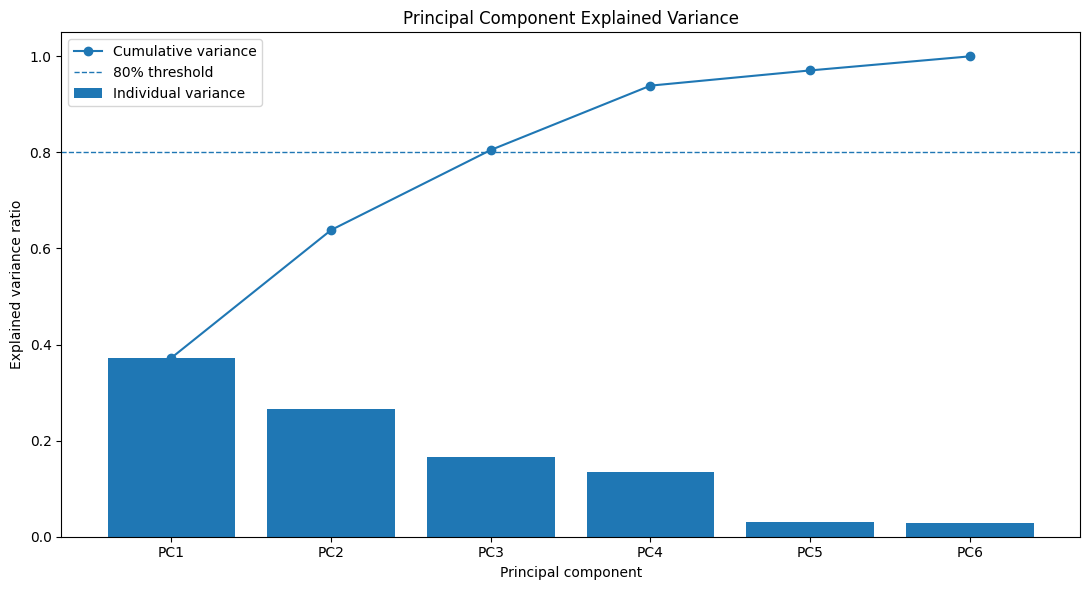

In [ ]:
plt.figure(figsize=(11, 6))

plt.bar(
    pca_explained_variance[
        "principal_component"
    ],
    pca_explained_variance[
        "explained_variance_ratio"
    ],
    label="Individual variance",
)

plt.plot(
    pca_explained_variance[
        "principal_component"
    ],
    pca_explained_variance[
        "cumulative_explained_variance"
    ],
    marker="o",
    label="Cumulative variance",
)

plt.axhline(
    y=0.80,
    linestyle="--",
    linewidth=1,
    label="80% threshold",
)

plt.title(
    "Principal Component Explained Variance"
)

plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.legend()
plt.tight_layout()
plt.show()

### Nombre de composantes pour 80 %

In [ ]:
PCA_VARIANCE_THRESHOLD = 0.80

number_of_components_80 = int(
    np.argmax(
        pca_explained_variance[
            "cumulative_explained_variance"
        ].to_numpy()
        >= PCA_VARIANCE_THRESHOLD
    )
    + 1
)

print(
    "Number of principal components required "
    f"to explain at least {PCA_VARIANCE_THRESHOLD:.0%}:",
    number_of_components_80,
)

Number of principal components required to explain at least 80%: 3


### Loadings de la première composante

In [ ]:
pc1_loadings = (
    pca_loadings["PC1"]
    .sort_values(
        key=np.abs,
        ascending=False,
    )
)

pc1_loadings.to_frame(
    "PC1_loading"
)

,PC1_loading
asset,
CORPORATE_BOND,0.534474
EUROPE_EQUITY,0.512501
US_EQUITY,0.482306
GOLD,0.336134
US_TREASURY,0.323255
EURUSD,0.039764


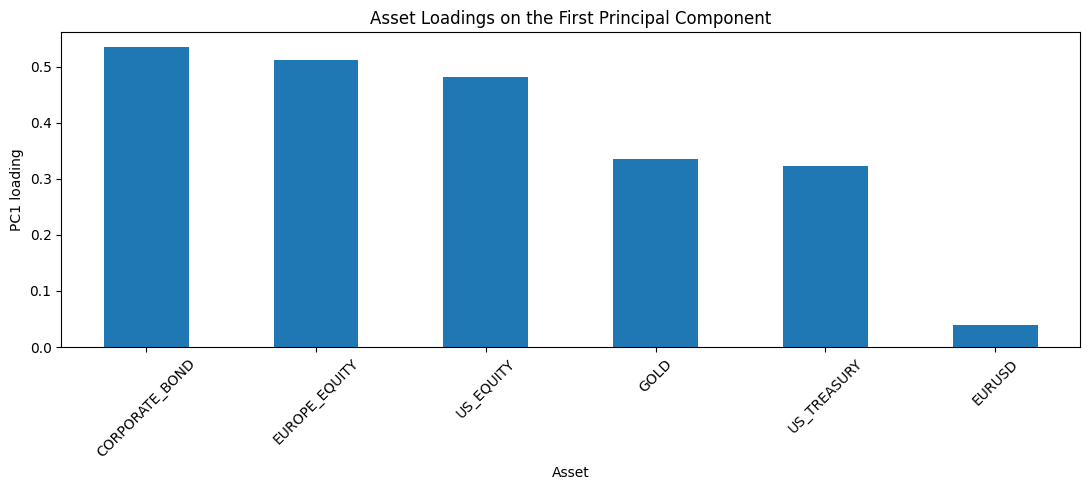

In [ ]:
pc1_loadings.plot(
    kind="bar",
    figsize=(11, 5),
    title="Asset Loadings on the First Principal Component",
)

plt.xlabel("Asset")
plt.ylabel("PC1 loading")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Matrice de covariance

### Covariance quotidienne et annualisée

In [ ]:
daily_covariance_matrix = (
    market_returns[
        portfolio_weights.index
    ]
    .cov()
)

annualized_covariance_matrix = (
    daily_covariance_matrix
    * TRADING_DAYS_PER_YEAR
)

annualized_covariance_matrix

asset,US_EQUITY,EUROPE_EQUITY,US_TREASURY,CORPORATE_BOND,GOLD,EURUSD
asset,,,,,,
US_EQUITY,0.035282,0.032595,-0.001358,0.005525,0.003643,0.000377
EUROPE_EQUITY,0.032595,0.045798,-0.000770,0.006773,0.007547,0.000045
US_TREASURY,-0.001358,-0.000770,0.004585,0.004290,0.003407,0.000102
CORPORATE_BOND,0.005525,0.006773,0.004290,0.008158,0.004218,0.000298
GOLD,0.003643,0.007547,0.003407,0.004218,0.027387,0.000084
EURUSD,0.000377,0.000045,0.000102,0.000298,0.000084,0.005071


## Contribution à la volatilité

### Fonction de contribution à la volatilité

In [ ]:
def calculate_volatility_contributions(
    weights: pd.Series,
    covariance_matrix: pd.DataFrame,
) -> pd.DataFrame:
    """Calculate marginal and component volatility."""

    aligned_assets = weights.index.tolist()

    aligned_covariance = (
        covariance_matrix
        .loc[
            aligned_assets,
            aligned_assets,
        ]
    )

    weight_vector = weights.to_numpy(
        dtype=float
    )

    covariance_values = (
        aligned_covariance.to_numpy(
            dtype=float
        )
    )

    portfolio_variance = float(
        weight_vector.T
        @ covariance_values
        @ weight_vector
    )

    if portfolio_variance <= 0:
        raise ValueError(
            "Portfolio variance must be positive."
        )

    portfolio_volatility = np.sqrt(
        portfolio_variance
    )

    marginal_volatility = (
        covariance_values
        @ weight_vector
        / portfolio_volatility
    )

    component_volatility = (
        weight_vector
        * marginal_volatility
    )

    percentage_contribution = (
        component_volatility
        / portfolio_volatility
    )

    result = pd.DataFrame(
        {
            "portfolio_weight":
                weight_vector,

            "marginal_volatility":
                marginal_volatility,

            "component_volatility":
                component_volatility,

            "percentage_contribution":
                percentage_contribution,
        },
        index=aligned_assets,
    )

    result.index.name = "asset"

    result["portfolio_volatility"] = (
        portfolio_volatility
    )

    return result

### Calculer les contributions

Nous utilisons les derniers poids réellement observés.

In [ ]:
volatility_contributions = (
    calculate_volatility_contributions(
        weights=actual_portfolio_weights, # Pass the Series directly
        covariance_matrix=
            annualized_covariance_matrix,
    )
)

volatility_contributions = (
    volatility_contributions.sort_values(
        "percentage_contribution",
        ascending=False,
    )
)

volatility_contributions

,portfolio_weight,marginal_volatility,component_volatility,percentage_contribution,portfolio_volatility
asset,,,,,
US_EQUITY,0.250000,0.165909,0.041477,0.422201,0.098240
EUROPE_EQUITY,0.200000,0.192687,0.038537,0.392277,0.098240
CORPORATE_BOND,0.150000,0.053635,0.008045,0.081893,0.098240
GOLD,0.100000,0.065974,0.006597,0.067156,0.098240
US_TREASURY,0.200000,0.014434,0.002887,0.029385,0.098240
EURUSD,0.100000,0.006962,0.000696,0.007087,0.098240


### Réconciliation

In [ ]:
portfolio_annualized_volatility = float(
    volatility_contributions[
        "portfolio_volatility"
    ].iloc[0]
)

component_volatility_sum = float(
    volatility_contributions[
        "component_volatility"
    ].sum()
)

assert np.isclose(
    component_volatility_sum,
    portfolio_annualized_volatility,
    atol=1e-10,
)

assert np.isclose(
    volatility_contributions[
        "percentage_contribution"
    ].sum(),
    1.0,
    atol=1e-10,
)

print(
    "Volatility contribution reconciliation successful."
)

print(
    "Annualized portfolio volatility:",
    portfolio_annualized_volatility,
)

Volatility contribution reconciliation successful.
Annualized portfolio volatility: 0.09824029183059682


### Graphique des contributions

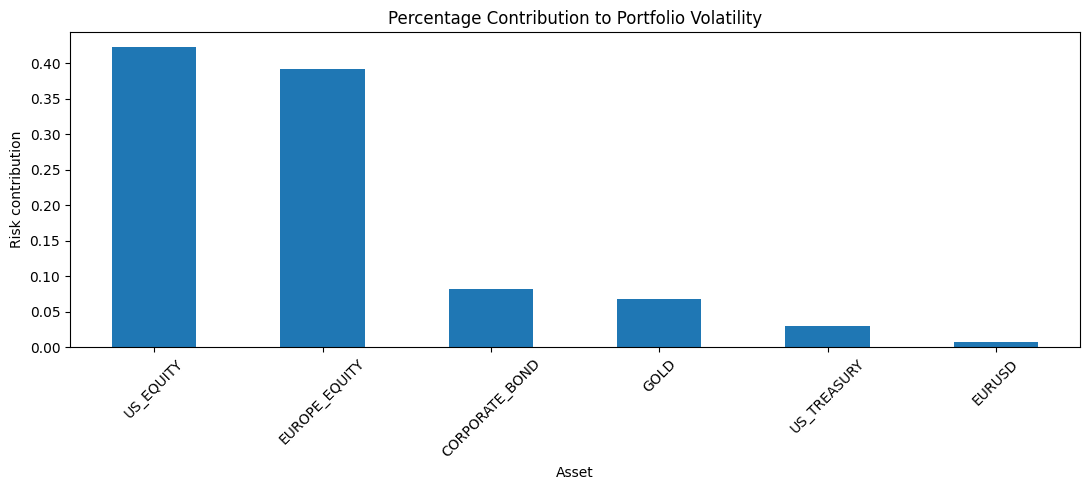

In [ ]:
volatility_contributions[
    "percentage_contribution"
].plot(
    kind="bar",
    figsize=(11, 5),
    title="Percentage Contribution to Portfolio Volatility",
)

plt.xlabel("Asset")
plt.ylabel("Risk contribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## VaR marginale et VaR composante

### Fonction Component VaR

In [ ]:
def calculate_component_var(
    weights: pd.Series,
    covariance_matrix: pd.DataFrame,
    portfolio_value: float,
    confidence_level: float = 0.99,
    expected_return: float = 0.0,
) -> pd.DataFrame:
    """Calculate marginal and component parametric VaR."""

    if portfolio_value <= 0:
        raise ValueError(
            "Portfolio value must be positive."
        )

    if not 0 < confidence_level < 1:
        raise ValueError(
            "Confidence level must be "
            "between zero and one."
        )

    assets = weights.index.tolist()

    aligned_covariance = (
        covariance_matrix.loc[
            assets,
            assets,
        ]
    )

    weight_vector = weights.to_numpy(
        dtype=float
    )

    covariance_values = (
        aligned_covariance.to_numpy(
            dtype=float
        )
    )

    portfolio_variance = float(
        weight_vector.T
        @ covariance_values
        @ weight_vector
    )

    portfolio_volatility = np.sqrt(
        portfolio_variance
    )

    alpha = 1 - confidence_level

    z_alpha = float(
        norm.ppf(alpha)
    )

    var_return = max(
        -(
            expected_return
            + z_alpha
            * portfolio_volatility
        ),
        0.0,
    )

    portfolio_var_amount = (
        var_return
        * portfolio_value
    )

    marginal_volatility = (
        covariance_values
        @ weight_vector
        / portfolio_volatility
    )

    volatility_contribution = (
        weight_vector
        * marginal_volatility
    )

    marginal_var = (
        -z_alpha
        * marginal_volatility
        * portfolio_value
    )

    component_var = (
        -z_alpha
        * volatility_contribution
        * portfolio_value
    )

    percentage_component_var = (
        component_var
        / portfolio_var_amount
    )

    result = pd.DataFrame(
        {
            "portfolio_weight":
                weight_vector,

            "marginal_volatility":
                marginal_volatility,

            "marginal_var":
                marginal_var,

            "component_var":
                component_var,

            "percentage_component_var":
                percentage_component_var,
        },
        index=assets,
    )

    result.index.name = "asset"

    result["portfolio_var_amount"] = (
        portfolio_var_amount
    )

    result["confidence_level"] = (
        confidence_level
    )

    return result

### Calculer la VaR composante

In [ ]:
COMPONENT_VAR_CONFIDENCE_LEVEL = 0.99

component_var_results = (
    calculate_component_var(
        weights=latest_actual_weights,
        covariance_matrix=
            daily_covariance_matrix,
        portfolio_value=
            latest_portfolio_value,
        confidence_level=
            COMPONENT_VAR_CONFIDENCE_LEVEL,
        expected_return=0.0,
    )
)

component_var_results = (
    component_var_results.sort_values(
        "component_var",
        ascending=False,
    )
)

component_var_results

,portfolio_weight,marginal_volatility,marginal_var,component_var,percentage_component_var,portfolio_var_amount,confidence_level
asset,,,,,,,
US_EQUITY,0.250000,0.010451,"48,612.756802","12,153.189201",0.422201,"28,785.303596",0.990000
EUROPE_EQUITY,0.200000,0.012138,"56,459.089149","11,291.817830",0.392277,"28,785.303596",0.990000
CORPORATE_BOND,0.150000,0.003379,"15,715.504552","2,357.325683",0.081893,"28,785.303596",0.990000
GOLD,0.100000,0.004156,"19,331.124612","1,933.112461",0.067156,"28,785.303596",0.990000
US_TREASURY,0.200000,0.000909,"4,229.342425",845.868485,0.029385,"28,785.303596",0.990000
EURUSD,0.100000,0.000439,"2,039.899366",203.989937,0.007087,"28,785.303596",0.990000


### Réconciliation de la VaR

In [ ]:
calculated_portfolio_var = float(
    component_var_results[
        "portfolio_var_amount"
    ].iloc[0]
)

component_var_sum = float(
    component_var_results[
        "component_var"
    ].sum()
)

assert np.isclose(
    component_var_sum,
    calculated_portfolio_var,
    atol=1e-6,
)

assert np.isclose(
    component_var_results[
        "percentage_component_var"
    ].sum(),
    1.0,
    atol=1e-8,
)

print(
    "Component VaR reconciliation successful."
)

print(
    "Parametric portfolio VaR 99%:",
    f"{calculated_portfolio_var:,.2f}",
)

Component VaR reconciliation successful.
Parametric portfolio VaR 99%: 28,785.30


### Visualiser la VaR composante

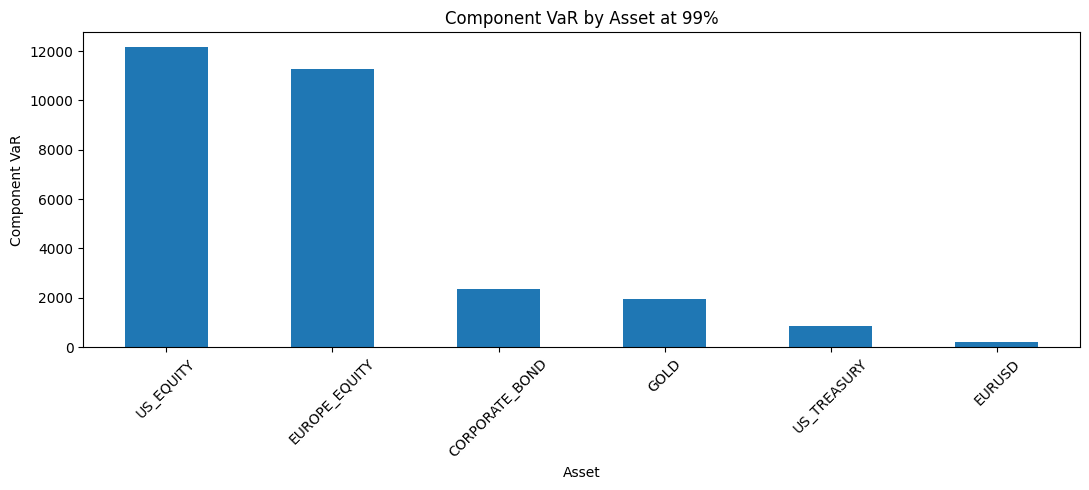

In [ ]:
component_var_results[
    "component_var"
].plot(
    kind="bar",
    figsize=(11, 5),
    title="Component VaR by Asset at 99%",
)

plt.xlabel("Asset")
plt.ylabel("Component VaR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Analyse de concentration

Plus l’indice est élevé, plus le portefeuille est concentré.

In [ ]:
def calculate_concentration_metrics(
    weights: pd.Series,
) -> pd.Series:
    """Calculate portfolio concentration indicators."""

    clean_weights = (
        weights.astype(float)
    )

    absolute_weights = (
        clean_weights.abs()
    )

    normalized_weights = (
        absolute_weights
        / absolute_weights.sum()
    )

    hhi = float(
        np.square(
            normalized_weights
        ).sum()
    )

    effective_number_of_positions = (
        1 / hhi
    )

    largest_weight = float(
        normalized_weights.max()
    )

    top_three_weight = float(
        normalized_weights
        .nlargest(3)
        .sum()
    )

    concentration_label = (
        "Low"
        if hhi < 0.15
        else "Moderate"
        if hhi < 0.25
        else "High"
    )

    return pd.Series({
        "herfindahl_hirschman_index":
            hhi,

        "effective_number_of_positions":
            effective_number_of_positions,

        "largest_position_weight":
            largest_weight,

        "top_three_positions_weight":
            top_three_weight,

        "number_of_positions":
            len(normalized_weights),

        "concentration_level":
            concentration_label,
    })

### Calculer les mesures

In [ ]:
concentration_metrics = (
    calculate_concentration_metrics(
        latest_actual_weights
    )
)

concentration_metrics.to_frame(
    "value"
)

,value
herfindahl_hirschman_index,0.185000
effective_number_of_positions,5.405405
largest_position_weight,0.250000
top_three_positions_weight,0.650000
number_of_positions,6
concentration_level,Moderate


### Concentration par facteur de risque

In [ ]:
latest_exposure_table = pd.DataFrame({
    "latest_weight":
        latest_actual_weights,

    "latest_market_value":
        position_market_values.iloc[-1],
})

latest_exposure_table = (
    latest_exposure_table.join(
        asset_reference[
            [
                "risk_factor",
                "description",
            ]
        ]
    )
)

risk_factor_concentration = (
    latest_exposure_table
    .groupby("risk_factor")
    .agg(
        total_weight=(
            "latest_weight",
            "sum",
        ),
        total_market_value=(
            "latest_market_value",
            "sum",
        ),
        number_of_assets=(
            "latest_weight",
            "size",
        ),
    )
    .sort_values(
        "total_weight",
        ascending=False,
    )
)

risk_factor_concentration

,total_weight,total_market_value,number_of_assets
risk_factor,,,
Equity,0.450000,"1,211,368.951927",2
Interest Rate,0.200000,"218,017.959718",1
Credit and Interest Rate,0.150000,"179,963.802687",1
Commodity,0.100000,"295,141.822304",1
Foreign Exchange,0.100000,"94,940.126794",1


## Résumé des mesures de risque

### Extraire les VaR et ES à 99 %

In [ ]:
risk_metrics_99 = (
    static_risk_metrics[
        static_risk_metrics[
            "confidence_level"
        ]
        == 0.99
    ]
    .copy()
    .sort_values(
        "var_amount",
        ascending=False,
    )
)

risk_metrics_99[
    [
        "model",
        "var_amount",
        "es_amount",
    ]
]

,model,var_amount,es_amount
10,Historical,"35,717.607647","52,141.525763"
12,Student-t,"34,621.196425","51,703.737037"
13,Monte Carlo Student-t,"34,442.076766","50,184.093055"
14,EWMA Gaussian,"29,900.817913",NaN
11,Gaussian,"29,774.887392","34,208.695162"


### électionner la mesure principale

Nous utiliserons la VaR historique à 99 % comme mesure centrale dans le rapport exécutif.

In [ ]:
historical_risk_99 = (
    risk_metrics_99[
        risk_metrics_99["model"]
        == "Historical"
    ]
    .iloc[0]
)

historical_var_99 = float(
    historical_risk_99[
        "var_amount"
    ]
)

historical_es_99 = float(
    historical_risk_99[
        "es_amount"
    ]
)

print(
    "Historical VaR 99%:",
    f"{historical_var_99:,.2f}",
)

print(
    "Historical ES 99%:",
    f"{historical_es_99:,.2f}",
)

Historical VaR 99%: 35,717.61
Historical ES 99%: 52,141.53


## Résumé du backtesting

### Résultats du modèle historique à 99 %

In [ ]:
historical_backtest_99 = (
    statistical_backtest_results[
        (
            statistical_backtest_results[
                "model"
            ]
            == "Historical"
        )
        & (
            statistical_backtest_results[
                "confidence_level"
            ]
            == 0.99
        )
    ]
    .iloc[0]
)

historical_basel_99 = (
    basel_traffic_light_results[
        basel_traffic_light_results[
            "model"
        ]
        == "Historical"
    ]
    .iloc[0]
)

historical_backtest_99

,5
model,Historical
confidence_level,0.990000
number_of_observations,1982
number_of_exceptions,34
expected_exception_rate,0.010000
observed_exception_rate,0.017154
kupiec_lr,8.440213
kupiec_p_value,0.003670
kupiec_result,Reject
independence_lr,5.351854


### Identifier les dépassements récents

In [ ]:
recent_exception_window = (
    var_backtest_detailed[
        (
            var_backtest_detailed[
                "model"
            ]
            == "Historical"
        )
        & (
            var_backtest_detailed[
                "confidence_level"
            ]
            == 0.99
        )
    ]
    .sort_values("date")
    .tail(250)
)

recent_exception_count = int(
    recent_exception_window[
        "exception"
    ].sum()
)

recent_exception_rate = float(
    recent_exception_window[
        "exception"
    ].mean()
)

print(
    "Recent 250-day exception count:",
    recent_exception_count,
)

print(
    "Recent exception rate:",
    f"{recent_exception_rate:.2%}",
)

Recent 250-day exception count: 3
Recent exception rate: 1.20%


## Résumé des stress tests

### Pire scénario historique

In [ ]:
successful_historical_stress = (
    historical_stress_results[
        historical_stress_results[
            "status"
        ]
        == "SUCCESS"
    ]
)

worst_historical_stress = (
    successful_historical_stress
    .sort_values(
        "total_pnl"
    )
    .iloc[0]
)

worst_historical_stress

,2
scenario,2022 Inflation and Rate Shock
requested_start_date,2022-01-03
requested_end_date,2022-10-12
actual_start_date,2022-01-03
actual_end_date,2022-10-12
number_of_observations,203
initial_value,"1,376,339.371999"
final_value,"1,078,324.050067"
total_return,-0.216527
total_pnl,"-298,015.321932"


### Pire scénario hypothétique

In [ ]:
worst_hypothetical_stress = (
    hypothetical_stress_results
    .sort_values(
        "stressed_pnl"
    )
    .iloc[0]
)

worst_hypothetical_stress

,0
scenario,Severe Global Crisis
portfolio_return,-0.200500
stressed_pnl,"-400,886.249018"
stress_loss,"400,886.249018"
initial_portfolio_value,"1,999,432.663429"
stressed_portfolio_value,"1,598,546.414412"


### Contributions au pire scénario

In [ ]:
worst_scenario_name = (
    worst_hypothetical_stress[
        "scenario"
    ]
)

worst_stress_contributions = (
    stress_asset_contributions[
        stress_asset_contributions[
            "scenario"
        ]
        == worst_scenario_name
    ]
    .sort_values(
        "pnl_contribution"
    )
)

worst_stress_contributions

,scenario,asset,latest_weight,market_shock,return_contribution,pnl_contribution
6,Severe Global Crisis,US_EQUITY,0.250000,-0.350000,-0.087500,"-174,950.358050"
7,Severe Global Crisis,EUROPE_EQUITY,0.200000,-0.400000,-0.080000,"-159,954.613074"
9,Severe Global Crisis,CORPORATE_BOND,0.150000,-0.180000,-0.027000,"-53,984.681913"
11,Severe Global Crisis,EURUSD,0.100000,-0.100000,-0.010000,"-19,994.326634"
8,Severe Global Crisis,US_TREASURY,0.200000,-0.030000,-0.006000,"-11,996.595981"
10,Severe Global Crisis,GOLD,0.100000,0.100000,0.010000,"19,994.326634"


### Indicateurs de performance du portefeuille

### Fonction de synthèse

In [ ]:
def calculate_final_portfolio_statistics(
    portfolio_returns: pd.Series,
    portfolio_value: pd.Series,
    daily_pnl: pd.Series,
    trading_days: int = 252,
) -> pd.Series:
    """Calculate final performance and risk statistics."""

    clean_returns = (
        portfolio_returns.dropna()
    )

    clean_pnl = (
        daily_pnl.dropna()
    )

    total_return = (
        portfolio_value.iloc[-1]
        / portfolio_value.iloc[0]
        - 1
    )

    annualized_return = (
        clean_returns.mean()
        * trading_days
    )

    annualized_volatility = (
        clean_returns.std(ddof=1)
        * np.sqrt(trading_days)
    )

    annualized_sharpe_ratio = (
        annualized_return
        / annualized_volatility
        if annualized_volatility > 0
        else np.nan
    )

    running_maximum = (
        portfolio_value.cummax()
    )

    drawdown = (
        portfolio_value
        / running_maximum
        - 1
    )

    return pd.Series({
        "initial_portfolio_value":
            portfolio_value.iloc[0],

        "latest_portfolio_value":
            portfolio_value.iloc[-1],

        "total_pnl":
            portfolio_value.iloc[-1]
            - portfolio_value.iloc[0],

        "total_return":
            total_return,

        "annualized_return":
            annualized_return,

        "annualized_volatility":
            annualized_volatility,

        "annualized_sharpe_ratio":
            annualized_sharpe_ratio,

        "maximum_drawdown":
            drawdown.min(),

        "maximum_drawdown_date":
            drawdown.idxmin(),

        "worst_daily_return":
            clean_returns.min(),

        "best_daily_return":
            clean_returns.max(),

        "worst_daily_pnl":
            clean_pnl.min(),

        "best_daily_pnl":
            clean_pnl.max(),

        "positive_return_rate":
            clean_returns.gt(0).mean(),

        "observation_count":
            len(clean_returns),
    })

### Calculer les statistiques finales

In [ ]:
final_portfolio_statistics = (
    calculate_final_portfolio_statistics(
        portfolio_returns=
            portfolio_returns,
        portfolio_value=
            portfolio_value,
        daily_pnl=
            portfolio_daily_pnl,
        trading_days=
            TRADING_DAYS_PER_YEAR,
    )
)

final_portfolio_statistics.to_frame(
    "value"
)

,value
initial_portfolio_value,"1,000,000.000000"
latest_portfolio_value,"1,999,432.663429"
total_pnl,"999,432.663429"
total_return,0.999433
annualized_return,0.083637
annualized_volatility,0.103882
annualized_sharpe_ratio,0.805117
maximum_drawdown,-0.221661
maximum_drawdown_date,2022-10-14 00:00:00
worst_daily_return,-0.056249


### Système simple de niveau de risque

Nous allons créer un indicateur synthétique:

LOW

MODERATE

HIGH

CRITICAL

Il ne remplace pas une décision humaine. Il sert uniquement à organiser le rapport.

### Fonction d’évaluation

In [ ]:
def determine_risk_level(
    var_percentage: float,
    stress_loss_percentage: float,
    maximum_drawdown: float,
    basel_zone: str,
    model_assessment: str,
) -> str:
    """Determine a simple overall risk level."""

    risk_score = 0

    if var_percentage >= 0.03:
        risk_score += 2
    elif var_percentage >= 0.02:
        risk_score += 1

    if stress_loss_percentage >= 0.20:
        risk_score += 3
    elif stress_loss_percentage >= 0.10:
        risk_score += 2
    elif stress_loss_percentage >= 0.05:
        risk_score += 1

    if maximum_drawdown <= -0.20:
        risk_score += 2
    elif maximum_drawdown <= -0.10:
        risk_score += 1

    if basel_zone == "Red":
        risk_score += 3
    elif basel_zone == "Yellow":
        risk_score += 1

    if model_assessment != "Acceptable":
        risk_score += 1

    if risk_score >= 7:
        return "CRITICAL"

    if risk_score >= 5:
        return "HIGH"

    if risk_score >= 2:
        return "MODERATE"

    return "LOW"

###  Calculer le niveau de risque

In [ ]:
var_percentage = (
    historical_var_99
    / latest_portfolio_value
)

worst_stress_loss = float(
    worst_hypothetical_stress[
        "stress_loss"
    ]
)

stress_loss_percentage = (
    worst_stress_loss
    / latest_portfolio_value
)

overall_risk_level = (
    determine_risk_level(
        var_percentage=
            var_percentage,

        stress_loss_percentage=
            stress_loss_percentage,

        maximum_drawdown=float(
            final_portfolio_statistics[
                "maximum_drawdown"
            ]
        ),

        basel_zone=str(
            historical_basel_99[
                "traffic_light_zone"
            ]
        ),

        model_assessment=str(
            historical_backtest_99[
                "overall_model_assessment"
            ]
        ),
    )
)

print(
    "Overall risk level:",
    overall_risk_level,
)

Overall risk level: HIGH


## Générer des constats automatiques

### Principaux contributeurs

In [ ]:
largest_position_asset = (
    latest_actual_weights.idxmax()
)

largest_position_weight = float(
    latest_actual_weights.max()
)

largest_volatility_contributor = (
    volatility_contributions[
        "percentage_contribution"
    ]
    .idxmax()
)

largest_volatility_contribution = float(
    volatility_contributions.loc[
        largest_volatility_contributor,
        "percentage_contribution",
    ]
)

largest_var_contributor = (
    component_var_results[
        "component_var"
    ]
    .idxmax()
)

largest_var_contribution = float(
    component_var_results.loc[
        largest_var_contributor,
        "component_var",
    ]
)

### Créer les constats

In [ ]:
automated_findings = [
    (
        f"The portfolio's largest position is "
        f"{largest_position_asset}, representing "
        f"{largest_position_weight:.2%} of current exposure."
    ),

    (
        f"The largest contributor to portfolio volatility is "
        f"{largest_volatility_contributor}, accounting for "
        f"{largest_volatility_contribution:.2%} of total volatility."
    ),

    (
        f"The largest component VaR contribution is generated by "
        f"{largest_var_contributor}, with a contribution of "
        f"{largest_var_contribution:,.2f}."
    ),

    (
        f"The one-day Historical VaR at 99% is "
        f"{historical_var_99:,.2f}, equivalent to "
        f"{var_percentage:.2%} of current portfolio value."
    ),

    (
        f"The Historical Expected Shortfall at 99% is "
        f"{historical_es_99:,.2f}."
    ),

    (
        f"The Historical VaR model is classified in the "
        f"{historical_basel_99['traffic_light_zone']} Basel zone."
    ),

    (
        f"The worst hypothetical scenario is "
        f"{worst_scenario_name}, with an estimated loss of "
        f"{worst_stress_loss:,.2f}, or "
        f"{stress_loss_percentage:.2%} of portfolio value."
    ),

    (
        f"{number_of_components_80} principal components explain "
        f"at least {PCA_VARIANCE_THRESHOLD:.0%} of standardized "
        f"asset-return variance."
    ),
]

for finding in automated_findings:
    print("-", finding)

- The portfolio's largest position is US_EQUITY, representing 25.00% of current exposure.
- The largest contributor to portfolio volatility is US_EQUITY, accounting for 42.22% of total volatility.
- The largest component VaR contribution is generated by US_EQUITY, with a contribution of 12,153.19.
- The one-day Historical VaR at 99% is 35,717.61, equivalent to 1.79% of current portfolio value.
- The Historical Expected Shortfall at 99% is 52,141.53.
- The Historical VaR model is classified in the Green Basel zone.
- The worst hypothetical scenario is Severe Global Crisis, with an estimated loss of 400,886.25, or 20.05% of portfolio value.
- 3 principal components explain at least 80% of standardized asset-return variance.


## Construire le rapport exécutif

### Rapport synthétique

In [ ]:
executive_risk_summary = {
    "report_date":
        str(report_date.date()),

    "pipeline_status":
        "SUCCESS",

    "overall_risk_level":
        overall_risk_level,

    "portfolio": {
        "name":
            notebook_04_manifest[
                "portfolio_name"
            ],

        "initial_value":
            float(
                final_portfolio_statistics[
                    "initial_portfolio_value"
                ]
            ),

        "current_value":
            latest_portfolio_value,

        "total_pnl":
            float(
                final_portfolio_statistics[
                    "total_pnl"
                ]
            ),

        "total_return":
            float(
                final_portfolio_statistics[
                    "total_return"
                ]
            ),

        "annualized_return":
            float(
                final_portfolio_statistics[
                    "annualized_return"
                ]
            ),

        "annualized_volatility":
            float(
                final_portfolio_statistics[
                    "annualized_volatility"
                ]
            ),

        "maximum_drawdown":
            float(
                final_portfolio_statistics[
                    "maximum_drawdown"
                ]
            ),
    },

    "market_risk": {
        "historical_var_99":
            historical_var_99,

        "historical_var_99_percentage":
            var_percentage,

        "historical_es_99":
            historical_es_99,

        "component_var_99":
            calculated_portfolio_var,

        "largest_var_contributor":
            largest_var_contributor,

        "largest_var_contribution":
            largest_var_contribution,
    },

    "backtesting": {
        "number_of_observations":
            int(
                historical_backtest_99[
                    "number_of_observations"
                ]
            ),

        "number_of_exceptions":
            int(
                historical_backtest_99[
                    "number_of_exceptions"
                ]
            ),

        "observed_exception_rate":
            float(
                historical_backtest_99[
                    "observed_exception_rate"
                ]
            ),

        "kupiec_p_value":
            float(
                historical_backtest_99[
                    "kupiec_p_value"
                ]
            ),

        "independence_p_value":
            float(
                historical_backtest_99[
                    "independence_p_value"
                ]
            ),

        "conditional_coverage_p_value":
            float(
                historical_backtest_99[
                    "conditional_coverage_p_value"
                ]
            ),

        "model_assessment":
            str(
                historical_backtest_99[
                    "overall_model_assessment"
                ]
            ),

        "basel_zone":
            str(
                historical_basel_99[
                    "traffic_light_zone"
                ]
            ),
    },

    "stress_testing": {
        "worst_historical_scenario":
            str(
                worst_historical_stress[
                    "scenario"
                ]
            ),

        "worst_historical_pnl":
            float(
                worst_historical_stress[
                    "total_pnl"
                ]
            ),

        "worst_historical_drawdown":
            float(
                worst_historical_stress[
                    "maximum_drawdown"
                ]
            ),

        "worst_hypothetical_scenario":
            worst_scenario_name,

        "worst_hypothetical_loss":
            worst_stress_loss,

        "worst_hypothetical_loss_percentage":
            stress_loss_percentage,
    },

    "concentration": {
        "hhi":
            float(
                concentration_metrics[
                    "herfindahl_hirschman_index"
                ]
            ),

        "effective_number_of_positions":
            float(
                concentration_metrics[
                    "effective_number_of_positions"
                ]
            ),

        "largest_position":
            largest_position_asset,

        "largest_position_weight":
            largest_position_weight,

        "concentration_level":
            str(
                concentration_metrics[
                    "concentration_level"
                ]
            ),
    },

    "factor_analysis": {
        "number_of_components_for_80_percent":
            number_of_components_80,

        "first_component_variance_ratio":
            float(
                pca_explained_variance.loc[
                    0,
                    "explained_variance_ratio",
                ]
            ),

        "largest_volatility_contributor":
            largest_volatility_contributor,

        "largest_volatility_contribution":
            largest_volatility_contribution,
    },

    "automated_findings":
        automated_findings,
}

In [ ]:
executive_risk_summary

{'report_date': '2026-07-29',
 'pipeline_status': 'SUCCESS',
 'overall_risk_level': 'HIGH',
 'portfolio': {'name': 'Global Multi-Asset Risk Portfolio',
  'initial_value': 1000000.0,
  'current_value': 1999432.663429188,
  'total_pnl': 999432.6634291881,
  'total_return': 0.9994326634291881,
  'annualized_return': 0.08363742594360175,
  'annualized_volatility': 0.10388238403642892,
  'maximum_drawdown': -0.22166131197220795},
 'market_risk': {'historical_var_99': 35717.60764694786,
  'historical_var_99_percentage': 0.017863871237198497,
  'historical_es_99': 52141.52576281825,
  'component_var_99': 28785.30359592948,
  'largest_var_contributor': 'US_EQUITY',
  'largest_var_contribution': 12153.189200524346},
 'backtesting': {'number_of_observations': 1982,
  'number_of_exceptions': 34,
  'observed_exception_rate': 0.0171543895055499,
  'kupiec_p_value': 0.0036701317039411,
  'independence_p_value': 0.0207002480888009,
  'conditional_coverage_p_value': 0.0010117905221746,
  'model_assess

## Construire le rapport tabulaire final

### Rapport principal

In [ ]:
final_risk_report = pd.DataFrame({
    "report_date": [
        report_date.date()
    ],

    "overall_risk_level": [
        overall_risk_level
    ],

    "portfolio_value": [
        latest_portfolio_value
    ],

    "total_pnl": [
        final_portfolio_statistics[
            "total_pnl"
        ]
    ],

    "total_return": [
        final_portfolio_statistics[
            "total_return"
        ]
    ],

    "annualized_return": [
        final_portfolio_statistics[
            "annualized_return"
        ]
    ],

    "annualized_volatility": [
        final_portfolio_statistics[
            "annualized_volatility"
        ]
    ],

    "maximum_drawdown": [
        final_portfolio_statistics[
            "maximum_drawdown"
        ]
    ],

    "historical_var_99": [
        historical_var_99
    ],

    "historical_var_99_percentage": [
        var_percentage
    ],

    "historical_es_99": [
        historical_es_99
    ],

    "component_var_99": [
        calculated_portfolio_var
    ],

    "var_exception_count": [
        historical_backtest_99[
            "number_of_exceptions"
        ]
    ],

    "var_exception_rate": [
        historical_backtest_99[
            "observed_exception_rate"
        ]
    ],

    "kupiec_p_value": [
        historical_backtest_99[
            "kupiec_p_value"
        ]
    ],

    "independence_p_value": [
        historical_backtest_99[
            "independence_p_value"
        ]
    ],

    "conditional_coverage_p_value": [
        historical_backtest_99[
            "conditional_coverage_p_value"
        ]
    ],

    "backtest_assessment": [
        historical_backtest_99[
            "overall_model_assessment"
        ]
    ],

    "basel_zone": [
        historical_basel_99[
            "traffic_light_zone"
        ]
    ],

    "worst_historical_scenario": [
        worst_historical_stress[
            "scenario"
        ]
    ],

    "worst_historical_pnl": [
        worst_historical_stress[
            "total_pnl"
        ]
    ],

    "worst_hypothetical_scenario": [
        worst_scenario_name
    ],

    "worst_hypothetical_loss": [
        worst_stress_loss
    ],

    "worst_hypothetical_loss_percentage": [
        stress_loss_percentage
    ],

    "largest_position": [
        largest_position_asset
    ],

    "largest_position_weight": [
        largest_position_weight
    ],

    "largest_var_contributor": [
        largest_var_contributor
    ],

    "largest_volatility_contributor": [
        largest_volatility_contributor
    ],

    "concentration_hhi": [
        concentration_metrics[
            "herfindahl_hirschman_index"
        ]
    ],

    "effective_number_of_positions": [
        concentration_metrics[
            "effective_number_of_positions"
        ]
    ],

    "pca_components_for_80_percent": [
        number_of_components_80
    ],
})

final_risk_report.T

,0
report_date,2026-07-29
overall_risk_level,HIGH
portfolio_value,"1,999,432.663429"
total_pnl,"999,432.663429"
total_return,0.999433
annualized_return,0.083637
annualized_volatility,0.103882
maximum_drawdown,-0.221661
historical_var_99,"35,717.607647"
historical_var_99_percentage,0.017864


## Construire les données du dashboard

### Table quotidienne consolidée

In [ ]:
final_dashboard_data = (
    portfolio_timeseries.copy()
)

dashboard_forecast_columns = [
    "historical_var_95_amount",
    "historical_var_99_amount",
    "gaussian_var_95_amount",
    "gaussian_var_99_amount",
    "ewma_var_95_amount",
    "ewma_var_99_amount",
    "historical_es_95_amount",
    "historical_es_99_amount",
]

available_forecast_columns = [
    column
    for column
    in dashboard_forecast_columns
    if column
    in rolling_risk_forecasts.columns
]

final_dashboard_data = (
    final_dashboard_data.join(
        rolling_risk_forecasts[
            available_forecast_columns
        ],
        how="left",
    )
)

final_dashboard_data = (
    final_dashboard_data.join(
        rolling_average_correlation,
        how="left",
    )
)

final_dashboard_data.head()

,portfolio_value,portfolio_return,daily_pnl,cumulative_pnl,drawdown,rolling_20d_volatility,rolling_60d_volatility,historical_var_95_amount,historical_var_99_amount,gaussian_var_95_amount,gaussian_var_99_amount,ewma_var_95_amount,ewma_var_99_amount,historical_es_95_amount,historical_es_99_amount,average_pairwise_correlation
date,,,,,,,,,,,,,,,,
2018-01-02,"1,000,000.000000",NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,"1,003,014.507203",0.003015,"3,014.507203","3,014.507203",0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,"1,007,570.505280",0.004542,"4,555.998077","7,570.505280",0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,"1,011,394.086659",0.003795,"3,823.581379","11,394.086659",0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-08,"1,010,643.062040",-0.000743,-751.024618,"10,643.062040",-0.000743,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
final_dashboard_data.tail()

,portfolio_value,portfolio_return,daily_pnl,cumulative_pnl,drawdown,rolling_20d_volatility,rolling_60d_volatility,historical_var_95_amount,historical_var_99_amount,gaussian_var_95_amount,gaussian_var_99_amount,ewma_var_95_amount,ewma_var_99_amount,historical_es_95_amount,historical_es_99_amount,average_pairwise_correlation
date,,,,,,,,,,,,,,,,
2026-07-23,"1,989,509.247349",-0.012318,"-24,813.268222","989,509.247349",-0.030405,0.097974,0.125107,"23,848.079302","39,002.859642","21,976.329049","31,567.789746","22,079.315671","31,507.558185","33,005.608297","43,181.011804",0.408701
2026-07-24,"1,993,812.306882",0.002163,"4,303.059533","993,812.306882",-0.028308,0.097913,0.125158,"24,269.326708","38,522.406085","21,945.059238","31,481.381978","21,170.612432","30,214.226530","32,623.944607","42,649.090019",0.404614
2026-07-27,"2,000,370.124522",0.003289,"6,557.817640","1,000,370.124522",-0.025112,0.095153,0.123327,"24,321.818225","38,605.725229","21,998.563065","31,551.584258","22,743.359366","32,439.860497","32,694.506117","42,741.334664",0.405302
2026-07-28,"1,999,146.618600",-0.000612,"-1,223.505922","999,146.618600",-0.025708,0.093640,0.121809,"24,401.814746","38,732.702731","22,072.211365","31,655.310895","22,166.844947","31,626.484056","32,802.041118","42,881.914536",0.403281
2026-07-29,"1,999,432.663429",0.000143,286.044829,"999,432.663429",-0.025569,0.093273,0.115696,"24,386.889626","38,709.012270","22,083.619905","31,658.588434","21,617.072832","30,848.411873","32,781.978085","42,855.686251",0.378543


### Ajouter les exceptions historiques à 99 %

In [ ]:
historical_99_exceptions = (
    var_backtest_detailed[
        (
            var_backtest_detailed[
                "model"
            ]
            == "Historical"
        )
        & (
            var_backtest_detailed[
                "confidence_level"
            ]
            == 0.99
        )
    ]
    .set_index("date")[
        "exception"
    ]
    .rename(
        "historical_var_99_exception"
    )
)

final_dashboard_data = (
    final_dashboard_data.join(
        historical_99_exceptions,
        how="left",
    )
)

final_dashboard_data[
    "historical_var_99_exception"
] = (
    final_dashboard_data[
        "historical_var_99_exception"
    ]
    .fillna(False)
    .astype(bool)
)

final_dashboard_data.tail()

,portfolio_value,portfolio_return,daily_pnl,cumulative_pnl,drawdown,rolling_20d_volatility,rolling_60d_volatility,historical_var_95_amount,historical_var_99_amount,gaussian_var_95_amount,gaussian_var_99_amount,ewma_var_95_amount,ewma_var_99_amount,historical_es_95_amount,historical_es_99_amount,average_pairwise_correlation,historical_var_99_exception
date,,,,,,,,,,,,,,,,,
2026-07-23,"1,989,509.247349",-0.012318,"-24,813.268222","989,509.247349",-0.030405,0.097974,0.125107,"23,848.079302","39,002.859642","21,976.329049","31,567.789746","22,079.315671","31,507.558185","33,005.608297","43,181.011804",0.408701,False
2026-07-24,"1,993,812.306882",0.002163,"4,303.059533","993,812.306882",-0.028308,0.097913,0.125158,"24,269.326708","38,522.406085","21,945.059238","31,481.381978","21,170.612432","30,214.226530","32,623.944607","42,649.090019",0.404614,False
2026-07-27,"2,000,370.124522",0.003289,"6,557.817640","1,000,370.124522",-0.025112,0.095153,0.123327,"24,321.818225","38,605.725229","21,998.563065","31,551.584258","22,743.359366","32,439.860497","32,694.506117","42,741.334664",0.405302,False
2026-07-28,"1,999,146.618600",-0.000612,"-1,223.505922","999,146.618600",-0.025708,0.093640,0.121809,"24,401.814746","38,732.702731","22,072.211365","31,655.310895","22,166.844947","31,626.484056","32,802.041118","42,881.914536",0.403281,False
2026-07-29,"1,999,432.663429",0.000143,286.044829,"999,432.663429",-0.025569,0.093273,0.115696,"24,386.889626","38,709.012270","22,083.619905","31,658.588434","21,617.072832","30,848.411873","32,781.978085","42,855.686251",0.378543,False


## Validation finale du rapport

### Contrôles de cohérence

In [ ]:
def validate_final_outputs(
    final_report: pd.DataFrame,
    dashboard_data: pd.DataFrame,
    volatility_contributions: pd.DataFrame,
    component_var: pd.DataFrame,
    pca_variance: pd.DataFrame,
) -> None:
    """Validate the final reporting outputs."""

    if final_report.empty:
        raise ValueError(
            "Final risk report is empty."
        )

    if dashboard_data.empty:
        raise ValueError(
            "Dashboard data are empty."
        )

    if volatility_contributions.empty:
        raise ValueError(
            "Volatility contributions are empty."
        )

    if component_var.empty:
        raise ValueError(
            "Component VaR results are empty."
        )

    if pca_variance.empty:
        raise ValueError(
            "PCA results are empty."
        )

    if not np.isclose(
        volatility_contributions[
            "percentage_contribution"
        ].sum(),
        1.0,
        atol=1e-8,
    ):
        raise ValueError(
            "Volatility contributions "
            "do not sum to one."
        )

    if not np.isclose(
        component_var[
            "component_var"
        ].sum(),
        component_var[
            "portfolio_var_amount"
        ].iloc[0],
        atol=1e-6,
    ):
        raise ValueError(
            "Component VaR does not reconcile."
        )

    cumulative_variance = (
        pca_variance[
            "cumulative_explained_variance"
        ]
    )

    if not cumulative_variance.is_monotonic_increasing:
        raise ValueError(
            "PCA cumulative variance "
            "is not increasing."
        )

    if cumulative_variance.iloc[-1] < 0.999:
        raise ValueError(
            "PCA explained variance "
            "does not sum to approximately one."
        )

    print("Final output validation successful.")


validate_final_outputs(
    final_report=final_risk_report,
    dashboard_data=final_dashboard_data,
    volatility_contributions=
        volatility_contributions,
    component_var=
        component_var_results,
    pca_variance=
        pca_explained_variance,
)

Final output validation successful.


## Enregistrer les sorties finales

### Définir les fichiers

In [ ]:
NOTEBOOK_05_OUTPUTS = {
    "final_risk_report_csv": (
        REPORTS_DIR
        / "final_risk_report.csv"
    ),

    "executive_risk_summary_json": (
        REPORTS_DIR
        / "executive_risk_summary.json"
    ),

    "final_portfolio_statistics_csv": (
        REPORTS_DIR
        / "final_portfolio_statistics.csv"
    ),

    "volatility_contributions_csv": (
        REPORTS_DIR
        / "volatility_contributions.csv"
    ),

    "component_var_csv": (
        REPORTS_DIR
        / "component_var.csv"
    ),

    "concentration_metrics_csv": (
        REPORTS_DIR
        / "concentration_metrics.csv"
    ),

    "risk_factor_concentration_csv": (
        REPORTS_DIR
        / "risk_factor_concentration.csv"
    ),

    "pca_explained_variance_csv": (
        REPORTS_DIR
        / "pca_explained_variance.csv"
    ),

    "pca_loadings_csv": (
        REPORTS_DIR
        / "pca_loadings.csv"
    ),

    "pca_scores_parquet": (
        DATA_PROCESSED_DIR
        / "pca_scores.parquet"
    ),

    "full_sample_correlation_csv": (
        REPORTS_DIR
        / "full_sample_correlation.csv"
    ),

    "rolling_average_correlation_parquet": (
        DATA_PROCESSED_DIR
        / "rolling_average_correlation.parquet"
    ),

    "rolling_asset_volatility_parquet": (
        DATA_PROCESSED_DIR
        / "rolling_asset_volatility.parquet"
    ),

    "final_dashboard_data_csv": (
        DATA_PROCESSED_DIR
        / "final_dashboard_data.csv"
    ),

    "final_dashboard_data_parquet": (
        DATA_PROCESSED_DIR
        / "final_dashboard_data.parquet"
    ),

    "automated_findings_txt": (
        REPORTS_DIR
        / "automated_findings.txt"
    ),

    "final_report_excel": (
        REPORTS_DIR
        / "market_risk_final_report.xlsx"
    ),
}

### Sauvegarder les fichiers CSV, Parquet et JSON

In [ ]:
final_risk_report.to_csv(
    NOTEBOOK_05_OUTPUTS[
        "final_risk_report_csv"
    ],
    index=False,
)

with open(
    NOTEBOOK_05_OUTPUTS[
        "executive_risk_summary_json"
    ],
    "w",
    encoding="utf-8",
) as summary_file:
    json.dump(
        executive_risk_summary,
        summary_file,
        indent=4,
        ensure_ascii=False,
    )

final_portfolio_statistics.rename(
    "value"
).to_csv(
    NOTEBOOK_05_OUTPUTS[
        "final_portfolio_statistics_csv"
    ]
)

volatility_contributions.to_csv(
    NOTEBOOK_05_OUTPUTS[
        "volatility_contributions_csv"
    ]
)

component_var_results.to_csv(
    NOTEBOOK_05_OUTPUTS[
        "component_var_csv"
    ]
)

concentration_metrics.rename(
    "value"
).to_csv(
    NOTEBOOK_05_OUTPUTS[
        "concentration_metrics_csv"
    ]
)

risk_factor_concentration.to_csv(
    NOTEBOOK_05_OUTPUTS[
        "risk_factor_concentration_csv"
    ]
)

pca_explained_variance.to_csv(
    NOTEBOOK_05_OUTPUTS[
        "pca_explained_variance_csv"
    ],
    index=False,
)

pca_loadings.to_csv(
    NOTEBOOK_05_OUTPUTS[
        "pca_loadings_csv"
    ]
)

pca_scores.to_parquet(
    NOTEBOOK_05_OUTPUTS[
        "pca_scores_parquet"
    ]
)

full_sample_correlation.to_csv(
    NOTEBOOK_05_OUTPUTS[
        "full_sample_correlation_csv"
    ]
)

rolling_average_correlation.to_parquet(
    NOTEBOOK_05_OUTPUTS[
        "rolling_average_correlation_parquet"
    ]
)

rolling_asset_volatility.to_parquet(
    NOTEBOOK_05_OUTPUTS[
        "rolling_asset_volatility_parquet"
    ]
)

final_dashboard_data.to_csv(
    NOTEBOOK_05_OUTPUTS[
        "final_dashboard_data_csv"
    ]
)

final_dashboard_data.to_parquet(
    NOTEBOOK_05_OUTPUTS[
        "final_dashboard_data_parquet"
    ]
)

with open(
    NOTEBOOK_05_OUTPUTS[
        "automated_findings_txt"
    ],
    "w",
    encoding="utf-8",
) as findings_file:

    for finding in automated_findings:
        findings_file.write(
            f"- {finding}\n"
        )

print(
    "CSV, Parquet, JSON and TXT outputs "
    "saved successfully."
)

CSV, Parquet, JSON and TXT outputs saved successfully.


## Créer un rapport Excel professionnel

### Rapport multi-feuilles

In [ ]:
with pd.ExcelWriter(
    NOTEBOOK_05_OUTPUTS[
        "final_report_excel"
    ],
    engine="openpyxl",
) as excel_writer:

    final_risk_report.to_excel(
        excel_writer,
        sheet_name="Executive Summary",
        index=False,
    )

    final_portfolio_statistics.rename(
        "value"
    ).to_frame().to_excel(
        excel_writer,
        sheet_name="Portfolio Statistics",
    )

    static_risk_metrics.to_excel(
        excel_writer,
        sheet_name="VaR and ES",
        index=False,
    )

    statistical_backtest_results.to_excel(
        excel_writer,
        sheet_name="Backtesting",
        index=False,
    )

    basel_traffic_light_results.to_excel(
        excel_writer,
        sheet_name="Basel Traffic Light",
        index=False,
    )

    historical_stress_results.to_excel(
        excel_writer,
        sheet_name="Historical Stress",
        index=False,
    )

    hypothetical_stress_results.to_excel(
        excel_writer,
        sheet_name="Hypothetical Stress",
        index=False,
    )

    volatility_contributions.to_excel(
        excel_writer,
        sheet_name="Volatility Contributions",
    )

    component_var_results.to_excel(
        excel_writer,
        sheet_name="Component VaR",
    )

    concentration_metrics.rename(
        "value"
    ).to_frame().to_excel(
        excel_writer,
        sheet_name="Concentration",
    )

    pca_explained_variance.to_excel(
        excel_writer,
        sheet_name="PCA Variance",
        index=False,
    )

    pca_loadings.to_excel(
        excel_writer,
        sheet_name="PCA Loadings",
    )

print(
    "Excel report saved to:",
    NOTEBOOK_05_OUTPUTS[
        "final_report_excel"
    ],
)

Excel report saved to: /content/drive/MyDrive/market-risk-analytics/reports/market_risk_final_report.xlsx


## Test de rechargement

### Vérifier les sorties finales

In [ ]:
reloaded_final_report = pd.read_csv(
    NOTEBOOK_05_OUTPUTS[
        "final_risk_report_csv"
    ]
)

reloaded_dashboard_data = pd.read_parquet(
    NOTEBOOK_05_OUTPUTS[
        "final_dashboard_data_parquet"
    ]
)

reloaded_component_var = pd.read_csv(
    NOTEBOOK_05_OUTPUTS[
        "component_var_csv"
    ],
    index_col=0,
)

with open(
    NOTEBOOK_05_OUTPUTS[
        "executive_risk_summary_json"
    ],
    "r",
    encoding="utf-8",
) as summary_file:
    reloaded_executive_summary = json.load(
        summary_file
    )

assert (
    reloaded_final_report.shape
    == final_risk_report.shape
)

assert (
    reloaded_dashboard_data.shape
    == final_dashboard_data.shape
)

assert (
    reloaded_component_var.shape
    == component_var_results.shape
)

assert (
    reloaded_executive_summary[
        "pipeline_status"
    ]
    == "SUCCESS"
)

print("Final output reloading test successful.")

Final output reloading test successful.


## Créer le manifeste final

### Fichiers essentiels pour Streamlit

In [ ]:
STREAMLIT_DEPENDENCIES = [
    NOTEBOOK_05_OUTPUTS[
        "final_dashboard_data_parquet"
    ],

    NOTEBOOK_05_OUTPUTS[
        "final_risk_report_csv"
    ],

    NOTEBOOK_05_OUTPUTS[
        "executive_risk_summary_json"
    ],

    NOTEBOOK_05_OUTPUTS[
        "volatility_contributions_csv"
    ],

    NOTEBOOK_05_OUTPUTS[
        "component_var_csv"
    ],

    NOTEBOOK_05_OUTPUTS[
        "pca_explained_variance_csv"
    ],

    NOTEBOOK_05_OUTPUTS[
        "pca_loadings_csv"
    ],

    NOTEBOOK_05_OUTPUTS[
        "risk_factor_concentration_csv"
    ],

    NOTEBOOK_05_REQUIRED_FILES[
        "static_risk_metrics"
    ],

    NOTEBOOK_05_REQUIRED_FILES[
        "var_backtest"
    ],

    NOTEBOOK_05_REQUIRED_FILES[
        "hypothetical_stress"
    ],
]

### Empreintes finales

In [ ]:
final_file_hashes = {
    file_path.name:
        calculate_file_hash(
            file_path
        )

    for file_path
    in STREAMLIT_DEPENDENCIES
}

final_file_hashes

{'final_dashboard_data.parquet': '7b038a4fc0638b9a13a32eed02bd40d3317bd14898aa2fe15d13fe342f7fa41c',
 'final_risk_report.csv': '5bee8f8841337d095625dc3d91e8b32b35c9606f1b4a088d65feef7c44ea2886',
 'executive_risk_summary.json': '934dd7cc390d5cdd116b4b9bf29b9cfbaddbf102a8a146ada082490e0e4d82f5',
 'volatility_contributions.csv': 'b0ec118e6993d38f41f45418c28e5e5482b634ed120c87b1ba0fb5173464cf92',
 'component_var.csv': 'd8fbbfb095f45db4081ce7e437d1c75980555fc87bf754d5ee2603c3d928ec46',
 'pca_explained_variance.csv': 'f235fbacdf9063f54c2c8ede2d099d7d5f4b694369a85e172eee3852cff61afc',
 'pca_loadings.csv': '21204bc1fe30f214ec5b00ab19e9364ac8d85eee81d35779b2f9cbf28e5678fc',
 'risk_factor_concentration.csv': '34b9787509328633df6c0c18f909c55811e24deb4704aed318babc077352eff4',
 'static_risk_metrics.parquet': 'c0411358656a2313f68a323a2948e2084c0a321eed326040d77d8fe7e71bca41',
 'var_backtest_detailed.parquet': 'ab141d82012ebb342565401ad58d85417d932bbfb497187304e1f477c4b7560b',
 'hypothetical_stress_

### Manifeste final

In [ ]:
FINAL_PIPELINE_MANIFEST_PATH = (
    CONFIG_DIR
    / "final_pipeline_manifest.json"
)

generation_time = datetime.now(
    timezone.utc
).isoformat()

final_pipeline_manifest = {
    "pipeline_name":
        "Market Risk Analytics Platform",

    "pipeline_version":
        notebook_04_manifest[
            "pipeline_version"
        ],

    "producer_notebook":
        "05_risk_factors_and_final_reporting.ipynb",

    "upstream_notebook":
        notebook_04_manifest[
            "producer_notebook"
        ],

    "upstream_manifest":
        str(
            NOTEBOOK_05_REQUIRED_FILES[
                "manifest"
            ]
            .relative_to(PROJECT_ROOT)
        ),

    "generated_at_utc":
        generation_time,

    "report_date":
        str(report_date.date()),

    "portfolio_name":
        notebook_04_manifest[
            "portfolio_name"
        ],

    "current_portfolio_value":
        latest_portfolio_value,

    "overall_risk_level":
        overall_risk_level,

    "historical_var_99":
        historical_var_99,

    "historical_es_99":
        historical_es_99,

    "worst_hypothetical_scenario":
        worst_scenario_name,

    "worst_hypothetical_loss":
        worst_stress_loss,

    "largest_var_contributor":
        largest_var_contributor,

    "largest_volatility_contributor":
        largest_volatility_contributor,

    "pca_components_for_80_percent":
        number_of_components_80,

    "streamlit_dependencies": [
        str(
            file_path.relative_to(
                PROJECT_ROOT
            )
        )
        for file_path
        in STREAMLIT_DEPENDENCIES
    ],

    "file_hashes":
        final_file_hashes,

    "pipeline_notebooks": [
        "01_data_collection_and_market_analysis.ipynb",
        "02_portfolio_and_pnl_analysis.ipynb",
        "03_var_and_expected_shortfall.ipynb",
        "04_backtesting_and_stress_testing.ipynb",
        "05_risk_factors_and_final_reporting.ipynb",
    ],

    "status":
        "SUCCESS",
}

with open(
    FINAL_PIPELINE_MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        final_pipeline_manifest,
        manifest_file,
        indent=4,
        ensure_ascii=False,
    )

print(
    "Final pipeline manifest saved to:",
    FINAL_PIPELINE_MANIFEST_PATH,
)

Final pipeline manifest saved to: /content/drive/MyDrive/market-risk-analytics/config/final_pipeline_manifest.json


## Validation finale du pipeline

### Vérifier le pipeline complet

In [ ]:
def validate_complete_pipeline(
    streamlit_dependencies: list[Path],
    final_manifest_path: Path,
) -> None:
    """Validate the complete Market Risk pipeline."""

    missing_files = [
        file_path
        for file_path
        in streamlit_dependencies
        if not file_path.exists()
    ]

    if missing_files:
        raise FileNotFoundError(
            "The complete pipeline is missing files: "
            f"{missing_files}"
        )

    empty_files = [
        file_path
        for file_path
        in streamlit_dependencies
        if file_path.stat().st_size == 0
    ]

    if empty_files:
        raise ValueError(
            "Empty final pipeline files: "
            f"{empty_files}"
        )

    if not final_manifest_path.exists():
        raise FileNotFoundError(
            "Final pipeline manifest is missing."
        )

    with open(
        final_manifest_path,
        "r",
        encoding="utf-8",
    ) as manifest_file:
        manifest = json.load(
            manifest_file
        )

    if manifest.get("status") != "SUCCESS":
        raise RuntimeError(
            "Final pipeline status is not SUCCESS."
        )

    if len(
        manifest.get(
            "pipeline_notebooks",
            [],
        )
    ) != 5:
        raise RuntimeError(
            "The final manifest does not contain "
            "the five expected notebooks."
        )

    print(
        "Complete Market Risk pipeline validated."
    )

    print(
        "All five notebooks completed successfully."
    )

    print(
        "The Streamlit dashboard can now be built."
    )


validate_complete_pipeline(
    streamlit_dependencies=
        STREAMLIT_DEPENDENCIES,
    final_manifest_path=
        FINAL_PIPELINE_MANIFEST_PATH,
)

Complete Market Risk pipeline validated.
All five notebooks completed successfully.
The Streamlit dashboard can now be built.


## Résumé final du notebook

### Tableau récapitulatif

In [ ]:
notebook_05_summary = pd.DataFrame({
    "indicator": [
        "Pipeline status",
        "Report date",
        "Overall risk level",
        "Current portfolio value",
        "Total portfolio P&L",
        "Annualized volatility",
        "Maximum drawdown",
        "Historical VaR 99%",
        "Historical ES 99%",
        "Basel zone",
        "Backtesting assessment",
        "Worst hypothetical scenario",
        "Worst hypothetical loss",
        "Largest position",
        "Largest VaR contributor",
        "Largest volatility contributor",
        "PCA components for 80%",
        "Concentration level",
        "Streamlit dependency files",
    ],

    "value": [
        "SUCCESS",
        report_date.date(),
        overall_risk_level,
        latest_portfolio_value,
        final_portfolio_statistics[
            "total_pnl"
        ],
        final_portfolio_statistics[
            "annualized_volatility"
        ],
        final_portfolio_statistics[
            "maximum_drawdown"
        ],
        historical_var_99,
        historical_es_99,
        historical_basel_99[
            "traffic_light_zone"
        ],
        historical_backtest_99[
            "overall_model_assessment"
        ],
        worst_scenario_name,
        worst_stress_loss,
        largest_position_asset,
        largest_var_contributor,
        largest_volatility_contributor,
        number_of_components_80,
        concentration_metrics[
            "concentration_level"
        ],
        len(STREAMLIT_DEPENDENCIES),
    ],
})

notebook_05_summary

,indicator,value
0,Pipeline status,SUCCESS
1,Report date,2026-07-29
2,Overall risk level,HIGH
3,Current portfolio value,"1,999,432.663429"
4,Total portfolio P&L,"999,432.663429"
5,Annualized volatility,0.103882
6,Maximum drawdown,-0.221661
7,Historical VaR 99%,"35,717.607647"
8,Historical ES 99%,"52,141.525763"
9,Basel zone,Green


## Conclusion

Notebook 05 successfully completed the Market Risk Analytics pipeline by consolidating portfolio performance, market-risk measures, model validation, stress testing and factor analysis into a final automated reporting layer.

### Risk-factor analysis

The notebook analyzed:

- full-sample asset correlations;
- rolling average correlations;
- static and rolling asset volatility;
- annualized portfolio volatility;
- asset-level contribution to volatility;
- marginal Value-at-Risk;
- component Value-at-Risk;
- portfolio concentration;
- concentration by risk factor;
- Principal Component Analysis.

### Reporting and model governance

The final report consolidates:

- current portfolio value;
- total and annualized performance;
- maximum drawdown;
- Historical VaR at 99%;
- Historical Expected Shortfall at 99%;
- VaR model comparisons;
- Kupiec backtesting results;
- Christoffersen independence results;
- conditional coverage results;
- Basel traffic-light classification;
- historical stress scenarios;
- hypothetical stress scenarios;
- asset-level stress contributions;
- concentration indicators;
- PCA results;
- automated risk findings.

### Pipeline controls

The final pipeline includes:

- explicit dependencies between notebooks;
- file-existence and file-size controls;
- SHA-256 integrity checks;
- input and output validation;
- P&L reconciliation;
- volatility-contribution reconciliation;
- component-VaR reconciliation;
- PCA explained-variance validation;
- CSV, Parquet, JSON and Excel exports;
- a final pipeline manifest;
- a complete loading test for the Streamlit application.

### Main limitations

- The portfolio contains linear market proxies rather than real trading-book instruments.
- Currency conversion is simplified.
- Transaction costs, bid-ask spreads and liquidity adjustments are excluded.
- VaR is calculated from daily end-of-day data.
- Nonlinear derivatives and option Greeks are not included.
- Stress scenarios use predefined shocks.
- The overall risk level is a simplified reporting indicator and does not replace expert judgement.
- PCA components are statistical factors and require economic interpretation.

### Final pipeline status

All five notebooks have been successfully connected:

1. Market data collection and validation;
2. Portfolio construction and P&L analysis;
3. VaR and Expected Shortfall;
4. Backtesting and stress testing;
5. Risk-factor analysis and final reporting.

The datasets required for the Streamlit dashboard are now available.

In [ ]:
PROJECT_ROOT = "/content/drive/MyDrive/market-risk-analytics"

In [ ]:
import shutil
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/market-risk-analytics")

ZIP_NAME = "/content/market-risk-analytics"

shutil.make_archive(
    base_name=ZIP_NAME,
    format="zip",
    root_dir=PROJECT_ROOT
)

print(f"Archive créée : {ZIP_NAME}.zip")

Archive créée : /content/market-risk-analytics.zip


In [ ]:
from google.colab import files

files.download("/content/market-risk-analytics.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/market-risk-analytics")

print("="*100)
print("LISTE DE TOUS LES FICHIERS")
print("="*100)

for file in sorted(PROJECT_ROOT.rglob("*")):
    if file.is_file():
        size = file.stat().st_size / (1024*1024)
        print(f"{size:8.2f} MB   {file.relative_to(PROJECT_ROOT)}")

LISTE DE TOUS LES FICHIERS
    0.00 MB   config/asset_reference.csv
    0.00 MB   config/final_pipeline_manifest.json
    0.00 MB   config/hypothetical_stress_scenarios.csv
    0.00 MB   config/notebook_02_manifest.json
    0.00 MB   config/notebook_03_manifest.json
    0.00 MB   config/notebook_04_manifest.json
    0.00 MB   config/pipeline_manifest.json
    0.00 MB   config/student_t_parameters.json
    0.13 MB   data/processed/asset_pnl_contributions.parquet
    0.66 MB   data/processed/final_dashboard_data.csv
    0.34 MB   data/processed/final_dashboard_data.parquet
    0.00 MB   data/processed/hypothetical_stress_results.parquet
    0.29 MB   data/processed/market_log_returns.csv
    0.14 MB   data/processed/market_log_returns.parquet
    0.26 MB   data/processed/market_prices.csv
    0.11 MB   data/processed/market_prices.parquet
    0.29 MB   data/processed/market_returns.csv
    0.14 MB   data/processed/market_returns.parquet
    0.14 MB   data/processed/pca_scores.parquet
   